# Quadriláteros: Definição, Elementos e Trapézios

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (ponto médio e distância entre dois pontos), [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (elementos do triângulo e soma dos ângulos internos), [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (casos de congruência como ferramenta de demonstração), [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (paralelas cortadas por uma transversal, colaterais internos e a demonstração do 180°) e [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (distância entre paralelas, que vira a altura do trapézio).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Definir quadrilátero e identificar seus elementos: vértices, lados consecutivos e opostos, ângulos internos e as duas diagonais.
- Calcular a soma dos ângulos internos de um quadrilátero qualquer, dividindo-o em dois triângulos por uma diagonal.
- Situar trapézios, paralelogramos, retângulos, losangos e quadrados no "mapa" dos quadriláteros notáveis.
- Classificar trapézios (escaleno, isósceles e retângulo) e aplicar suas propriedades, incluindo a base média e sua ligação com a base média do triângulo.

**Tempo estimado:** 60 a 75 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb)

## O que muda quando colocamos um quarto lado?

Nos últimos notebooks, o triângulo foi o protagonista. Em [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) você viu que ele é **rígido**: três varetas presas pelas pontas formam um triângulo que não se deforma. E em [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) descobriu o porquê: os três lados (caso LLL) já determinam o triângulo inteiro.

Agora pegue **quatro** varetas, duas de 4 dm e duas de 2,5 dm, e prenda as pontas com parafusos frouxos, formando um retângulo. Dê um empurrãozinho no canto de cima. O que acontece?

O retângulo **tomba** e vira uma figura "torta", sem que nenhuma vareta tenha mudado de tamanho (primeiro desenho abaixo). Ou seja:

> **com quatro lados, saber as medidas dos lados não basta para saber a forma da figura.**

É por isso que portões, porteiras e estantes ganham uma **escora diagonal**: ela divide o quadrilátero em dois triângulos, e triângulos não se deformam (segundo desenho). A porta sanfonada faz o contrário: é feita de quadriláteros articulados justamente **para** se deformar e dobrar.

Quadriláteros estão em toda parte, e muitos nem têm nome na linguagem do dia a dia: a tela do celular (um retângulo), um papel de presente dobrado torto (um quadrilátero qualquer), o perfil de uma calha de telhado ou de uma saia evasê (um trapézio). Neste notebook você vai:
- dar nome às partes de um quadrilátero e descobrir quantas diagonais ele tem;
- provar que os quatro ângulos internos de **qualquer** quadrilátero somam sempre o mesmo valor;
- montar o "mapa" dos quadriláteros notáveis, que continua no próximo notebook;
- estudar o primeiro deles, o **trapézio**, e a sua **base média**.

In [1]:
import math
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Ellipse, FancyBboxPatch, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas de desenho e de medida, as mesmas de 0407a_perpendicularidade
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=5)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")


def desenhar_reta(ax, ponto, inclinacao: float, cor: str = COR_SECUNDARIA, estilo: str = "-",
                  largura: float = 2.5, nome: str | None = None, posicao_nome=None) -> None:
    """Desenha a reta que passa por `ponto` com a inclinação dada (em graus). Uma reta é infinita:
    desenhamos um pedaço bem comprido e o próprio eixo corta o que sobra (por isso, chame
    `preparar_eixo` ANTES). O nome da reta (letra minúscula) vai em `posicao_nome`."""
    p = np.array(ponto, dtype=float)
    d = direcao(inclinacao)
    ax.plot(*zip(p - 100 * d, p + 100 * d), color=cor, lw=largura, linestyle=estilo)
    if nome and posicao_nome is not None:
        ax.text(*posicao_nome, nome, color=cor, fontsize=14, style="italic", fontweight="bold",
                ha="center", va="center")


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def marcar_angulo_reto(ax, vertice, p, q, tamanho: float = 0.3, cor: str = COR_DESTAQUE) -> None:
    """Desenha o quadradinho de ângulo reto no `vertice`, entre as semirretas que passam por p e por q."""
    v = np.array(vertice, dtype=float)
    u = np.subtract(p, v) / np.linalg.norm(np.subtract(p, v))
    w = np.subtract(q, v) / np.linalg.norm(np.subtract(q, v))
    canto = [v, v + tamanho * u, v + tamanho * (u + w), v + tamanho * w]
    ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2, zorder=4))


# Ferramentas novas deste notebook, para trabalhar com quadriláteros
def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas (0402a)."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def orientacao(O, P, Q) -> float:
    """A multiplicação cruzada do teste de colinearidade de 0401a, agora olhando também o SINAL:
    dá zero se O, P e Q são colineares, um número positivo se o caminho O → P → Q vira para a
    esquerda (sentido anti-horário) e um número negativo se vira para a direita (sentido horário)."""
    return (P[0] - O[0]) * (Q[1] - O[1]) - (P[1] - O[1]) * (Q[0] - O[0])


def area_com_sinal(vertices) -> float:
    """Área do polígono pela "fórmula do cadarço", com sinal: positiva se os vértices estão em
    sentido anti-horário e negativa se estão em sentido horário. Aqui só o SINAL nos interessa
    (as áreas ficam para o fim do módulo)."""
    n = len(vertices)
    return sum(orientacao((0, 0), vertices[k], vertices[(k + 1) % n]) for k in range(n)) / 2


def angulos_internos(vertices) -> list[float]:
    """Medidas (em graus) dos ângulos internos de um polígono simples, na ordem dos vértices.
    Num vértice "afundado" (de um polígono côncavo), o ângulo interno passa de 180°."""
    n = len(vertices)
    sentido = 1 if area_com_sinal(vertices) > 0 else -1
    angulos = []
    for k in range(n):
        anterior, vertice, proximo = vertices[k - 1], vertices[k], vertices[(k + 1) % n]
        angulo = medir_angulo(vertice, anterior, proximo)
        if orientacao(anterior, vertice, proximo) * sentido < 0:  # virou "para o lado errado"
            angulo = 360 - angulo
        angulos.append(angulo)
    return angulos


def segmentos_se_cruzam(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 se cruzam formando um "X": as pontas de cada um ficam em
    lados opostos da reta do outro."""
    return (orientacao(P1, P2, Q1) * orientacao(P1, P2, Q2) < 0
            and orientacao(Q1, Q2, P1) * orientacao(Q1, Q2, P2) < 0)


def tipo_de_quadrilatero(vertices) -> str:
    """'convexo', 'côncavo', 'cruzado' (dois lados se cruzam: não é simples) ou 'degenerado'
    (três vértices consecutivos colineares: não é quadrilátero)."""
    A, B, C, D = vertices
    giros = [orientacao(vertices[k - 1], vertices[k], vertices[(k + 1) % 4]) for k in range(4)]
    if any(math.isclose(g, 0, abs_tol=1e-9) for g in giros):
        return "degenerado"
    if segmentos_se_cruzam(A, B, C, D) or segmentos_se_cruzam(B, C, D, A):
        return "cruzado"
    if all(g > 0 for g in giros) or all(g < 0 for g in giros):
        return "convexo"
    return "côncavo"


def sao_paralelos(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 têm a mesma direção (inclinações iguais, a menos de 180°)."""
    diferenca = (direcao_de(P1, P2) - direcao_de(Q1, Q2)) % 180
    return math.isclose(diferenca, 0, abs_tol=1e-6) or math.isclose(diferenca, 180, abs_tol=1e-6)


def chapeu(letra: str) -> str:
    """Nome de ângulo com o chapéu (Â, B̂, ...), para títulos e rótulos dos gráficos."""
    return rf"$\hat{{{letra}}}$"


def desenhar_quadrilatero(ax, vertices, cor: str = COR_PONTO, largura: float = 2.5, estilo: str = "-",
                          preencher: bool = True) -> None:
    """Desenha os lados do polígono (na ordem dos vértices) e pinta levemente o interior."""
    if preencher:
        ax.add_patch(Polygon(vertices, closed=True, facecolor=cor, alpha=0.15, edgecolor="none"))
    n = len(vertices)
    for k in range(n):
        ax.plot(*zip(vertices[k], vertices[(k + 1) % n]), color=cor, lw=largura, linestyle=estilo)


def rotular_vertices(ax, vertices, nomes="ABCD", cor: str = COR_AVISO, distancia: float = 0.35,
                     tamanho: int = 13) -> None:
    """Marca os vértices e escreve os nomes do lado de fora da figura (afastando-se do centro dela)."""
    centro = np.mean(np.asarray(vertices, dtype=float), axis=0)
    for vertice, nome in zip(vertices, nomes):
        v = np.asarray(vertice, dtype=float)
        ax.plot(*v, "o", color=cor, markersize=7, zorder=5)
        afastar = v - centro
        afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
        ax.text(*(v + distancia * afastar), nome, color=NORD_TEXTO, fontsize=tamanho, fontweight="bold",
                ha="center", va="center")


def rotular_lado(ax, P, Q, texto: str, centro, cor: str = NORD_TEXTO_SEC, distancia: float = 0.3,
                 tamanho: int = 10) -> None:
    """Escreve `texto` junto ao meio do segmento PQ, do lado de fora da figura (longe de `centro`)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    meio = (P + Q) / 2
    normal = np.array([-(Q - P)[1], (Q - P)[0]]) / np.linalg.norm(Q - P)
    if np.dot(normal, meio - np.asarray(centro, dtype=float)) < 0:
        normal = -normal
    ax.text(*(meio + distancia * normal), texto, color=cor, fontsize=tamanho, ha="center", va="center",
            fontweight="bold")


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.16) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes (0402a)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2,
                zorder=6)


def desenhar_angulos_internos(ax, vertices, raio: float = 0.45, cores=None, raio_rotulo: float | None = None,
                              tamanho_fonte: int = 11) -> list[float]:
    """Pinta os ângulos internos do polígono com as medidas (o ângulo reto ganha o quadradinho)
    e devolve a lista das medidas."""
    angulos = angulos_internos(vertices)
    anti_horario = area_com_sinal(vertices) > 0
    n = len(vertices)
    cores = cores or [COR_DESTAQUE] * n
    for k, angulo in enumerate(angulos):
        vertice, anterior, proximo = vertices[k], vertices[k - 1], vertices[(k + 1) % n]
        # O interior fica à esquerda de quem anda no sentido anti-horário: o arco começa no lado
        # que sai do vértice e gira, no sentido anti-horário, até o lado que chega nele.
        inicio = direcao_de(vertice, proximo if anti_horario else anterior)
        desenhar_setor(ax, vertice, inicio, angulo, raio=raio, cor=cores[k], rotulo=f"{angulo:.0f}°",
                       raio_rotulo=1.9 * raio if raio_rotulo is None else raio_rotulo,
                       tamanho_fonte=tamanho_fonte)
    return angulos

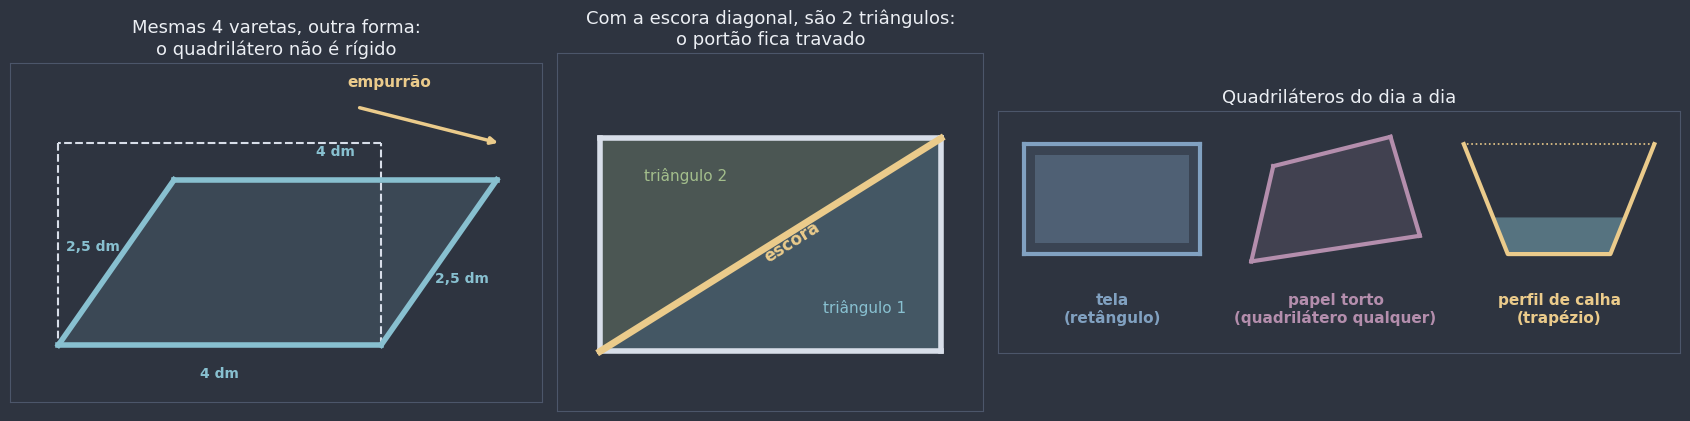

In [2]:
def quadrilatero_de_varetas(base: float, lateral: float, angulo_A: float) -> list[np.ndarray]:
    """Vértices A, B, C, D de um quadrilátero de varetas (lados base, lateral, base, lateral) com
    o ângulo em A dado, em graus. Com 90° é um retângulo; com outro valor, ele "tomba"."""
    A = np.array([0.0, 0.0])
    B = np.array([base, 0.0])
    D = lateral * direcao(angulo_A)
    return [A, B, B + D, D]


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={"width_ratios": [1.25, 1, 1.6]})
fig.patch.set_facecolor(NORD_FUNDO)

# 1) As mesmas quatro varetas formam um retângulo... ou uma figura "tombada"
retangulo = quadrilatero_de_varetas(4, 2.5, 90)
tombado = quadrilatero_de_varetas(4, 2.5, 55)
preparar_eixo(ax1, [(-0.5, -0.6), (5.9, 3.4)], margem=0.1)
desenhar_quadrilatero(ax1, retangulo, cor=NORD_TEXTO_SEC, largura=1.5, estilo="--", preencher=False)
desenhar_quadrilatero(ax1, tombado, cor=COR_PONTO, largura=4)
centro = np.mean(tombado, axis=0)
for k, medida in enumerate(["4 dm", "2,5 dm", "4 dm", "2,5 dm"]):
    rotular_lado(ax1, tombado[k], tombado[(k + 1) % 4], medida, centro, cor=COR_PONTO, distancia=0.35)
ax1.annotate("", xy=tombado[2] + (0.05, 0.45), xytext=retangulo[2] + (-0.3, 0.45),
             arrowprops=dict(arrowstyle="-|>", color=COR_AVISO, lw=2.5))
ax1.text(4.1, 3.2, "empurrão", color=COR_AVISO, fontsize=11, fontweight="bold", ha="center")
ax1.set_title("Mesmas 4 varetas, outra forma:\no quadrilátero não é rígido", color=NORD_TEXTO, fontsize=13)

# 2) Um portão com escora diagonal: dois triângulos, que não se deformam
A, B, C, D = quadrilatero_de_varetas(4, 2.5, 90)
preparar_eixo(ax2, [(-0.4, -0.6), (4.4, 3.4)], margem=0.1)
ax2.add_patch(Polygon([A, B, C], closed=True, facecolor=COR_PONTO, alpha=0.25, edgecolor="none"))
ax2.add_patch(Polygon([A, C, D], closed=True, facecolor=COR_DESTAQUE, alpha=0.25, edgecolor="none"))
desenhar_quadrilatero(ax2, [A, B, C, D], cor=NORD_TEXTO_SEC, largura=4, preencher=False)
ax2.plot(*zip(A, C), color=COR_AVISO, lw=5)
ax2.text(2.25, 1.05, "escora", color=COR_AVISO, fontsize=12, fontweight="bold", rotation=32, ha="center")
ax2.text(3.1, 0.45, "triângulo 1", color=COR_PONTO, fontsize=11, ha="center")
ax2.text(1.0, 2.0, "triângulo 2", color=COR_DESTAQUE, fontsize=11, ha="center")
ax2.set_title("Com a escora diagonal, são 2 triângulos:\no portão fica travado", color=NORD_TEXTO, fontsize=13)

# 3) Quadriláteros do dia a dia
preparar_eixo(ax3, [(-0.2, -1.0), (8.8, 2.0)], margem=0.15)
tela = [(0, 0.2), (2.4, 0.2), (2.4, 1.7), (0, 1.7)]
desenhar_quadrilatero(ax3, tela, cor=COR_SECUNDARIA, largura=3)
ax3.add_patch(Polygon([(0.15, 0.35), (2.25, 0.35), (2.25, 1.55), (0.15, 1.55)], closed=True,
                      facecolor=COR_SECUNDARIA, alpha=0.3, edgecolor="none"))
papel = [(3.1, 0.1), (5.4, 0.45), (5.0, 1.8), (3.4, 1.4)]
desenhar_quadrilatero(ax3, papel, cor=COR_EXTRA, largura=3)
calha = [(6.6, 0.2), (8.0, 0.2), (8.6, 1.7), (6.0, 1.7)]
ax3.add_patch(Polygon([(6.6, 0.2), (8.0, 0.2), (8.2, 0.7), (6.4, 0.7)], closed=True, facecolor=COR_PONTO,
                      alpha=0.45, edgecolor="none"))  # água no fundo da calha
ax3.plot(*zip(calha[3], calha[0], calha[1], calha[2]), color=COR_AVISO, lw=3)
ax3.plot(*zip(calha[2], calha[3]), color=COR_AVISO, lw=1.2, linestyle=":")  # a calha é aberta em cima
for x, texto, cor in [(1.2, "tela\n(retângulo)", COR_SECUNDARIA),
                      (4.25, "papel torto\n(quadrilátero qualquer)", COR_EXTRA),
                      (7.3, "perfil de calha\n(trapézio)", COR_AVISO)]:
    ax3.text(x, -0.55, texto, color=cor, fontsize=11, ha="center", va="center", fontweight="bold")
ax3.set_title("Quadriláteros do dia a dia", color=NORD_TEXTO, fontsize=13)

plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** o slider `empurrão` tomba o quadrilátero de varetas (lados 4; 2,5; 4; 2,5 dm). Repare que os lados **nunca** mudam, mas os ângulos e a diagonal $\overline{AC}$ (tracejada) mudam o tempo todo. Depois marque a caixa `escora diagonal AC` e tente empurrar de novo: com a diagonal presa, cada metade é um triângulo de três lados fixos, e o caso LLL de [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) não deixa nada se mexer.

In [ ]:
def explorar_varetas(empurrao: int, escora: bool) -> None:
    angulo_A = 90 if escora else 90 - empurrao
    vertices = quadrilatero_de_varetas(4, 2.5, angulo_A)
    A, B, C, D = vertices
    fig, ax = plt.subplots(figsize=(9.5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-0.7, -0.7), (6.5, 3.2)], margem=0)
    desenhar_quadrilatero(ax, vertices, cor=COR_PONTO, largura=4)
    desenhar_angulos_internos(ax, vertices, raio=0.42)
    centro = np.mean(vertices, axis=0)
    for k, medida in enumerate(["4", "2,5", "4", "2,5"]):
        rotular_lado(ax, vertices[k], vertices[(k + 1) % 4], medida, centro, cor=COR_PONTO, distancia=0.3)
    if escora:
        ax.plot(*zip(A, C), color=COR_AVISO, lw=5)
        titulo = (f"Com a escora AC ({math.dist(A, C):.2f} dm), os triângulos ABC e ACD têm os 3 lados fixos (LLL):\n"
                  "o empurrão não deforma nada. Desmarque a escora para ver o quadrilátero tombar.")
        cor = COR_AVISO
    else:
        ax.plot(*zip(A, C), color=NORD_TEXTO_SEC, lw=1.2, linestyle="--")
        titulo = (f"Lados 4; 2,5; 4; 2,5 (sempre os mesmos!), mas ângulo em A de {angulo_A}°\n"
                  f"e diagonal AC de {math.dist(A, C):.2f} dm: a forma mudou")
        cor = COR_PONTO
    rotular_vertices(ax, vertices)
    ax.set_title(titulo, color=cor, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_varetas,
    empurrao=widgets.IntSlider(value=25, min=0, max=60, step=5, description="empurrão (°):"),
    escora=widgets.Checkbox(value=False, description="escora diagonal AC"),
);

interactive(children=(IntSlider(value=25, description='empurrão (°):', max=60, step=5), Checkbox(value=False, …

O segredo da escora é transformar um quadrilátero em **dois triângulos**, e essa ideia vai aparecer o notebook inteiro. Na seção 1 vamos dar nome às partes de um quadrilátero; na seção 2, usar uma diagonal para descobrir a soma dos seus ângulos; na seção 3, montar o mapa dos quadriláteros "com nome próprio"; e, nas seções 4 e 5, estudar o **trapézio** e a sua **base média**.

## 1. O que é um quadrilátero e quais são seus elementos

Em [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb), o triângulo nasceu de **três** pontos não colineares. O quadrilátero segue a mesma receita com **quatro** pontos, mas com dois cuidados novos: a **ordem** dos pontos importa, e os lados **não podem se cruzar**.

📌 **Definição formal (quadrilátero):** sejam $A$, $B$, $C$ e $D$ quatro pontos de um plano, tais que **três consecutivos quaisquer não são colineares**. O **quadrilátero** $ABCD$ é a reunião dos segmentos $\overline{AB}$, $\overline{BC}$, $\overline{CD}$ e $\overline{DA}$, desde que esses segmentos **não se cruzem**: cada lado só encontra o lado seguinte e o anterior, e só nas pontas. Um quadrilátero assim é chamado de **simples**.

Os elementos do quadrilátero $ABCD$:

| Elemento | No quadrilátero $ABCD$ | Quantos? |
|---|---|---|
| vértices | $A$, $B$, $C$, $D$ | 4 |
| lados | $\overline{AB}$, $\overline{BC}$, $\overline{CD}$, $\overline{DA}$ | 4 |
| lados **consecutivos** (têm um vértice em comum) | $\overline{AB}$ e $\overline{BC}$; $\overline{BC}$ e $\overline{CD}$; $\overline{CD}$ e $\overline{DA}$; $\overline{DA}$ e $\overline{AB}$ | 4 pares |
| lados **opostos** (sem vértice em comum) | $\overline{AB}$ e $\overline{CD}$; $\overline{BC}$ e $\overline{DA}$ | 2 pares |
| ângulos internos | $\hat{A} = D\hat{A}B$, $\;\hat{B} = A\hat{B}C$, $\;\hat{C} = B\hat{C}D$, $\;\hat{D} = C\hat{D}A$ | 4 |
| **diagonais** (ligam vértices **não consecutivos**) | $\overline{AC}$ e $\overline{BD}$ | 2 |

Por que exatamente **duas** diagonais? Com 4 vértices dá para traçar $\dfrac{4 \cdot 3}{2} = 6$ segmentos ligando dois deles (a conta $n(n-1)/2$ de [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb)). Quatro desses segmentos ligam vértices **consecutivos** e já são os lados; sobram $6 - 4 = 2$, as diagonais. Ligar $A$ a $B$ não seria uma diagonal: seria o próprio lado $\overline{AB}$.

**No código**, um quadrilátero é só a lista dos seus quatro vértices, **na ordem**. A função `combinations`, do módulo `itertools`, gera todos os pares de vértices, e a gente separa quem é lado e quem é diagonal.

In [4]:
A, B, C, D = (np.array(p) for p in [(0.0, 0.0), (5.0, 0.6), (4.2, 3.6), (0.8, 2.8)])
quadrilatero = [A, B, C, D]
nomes = "ABCD"
ponto = dict(zip(nomes, quadrilatero))  # para achar o ponto pela letra: ponto["C"]

# Todos os segmentos que ligam dois vértices: as combinações das 4 letras, 2 a 2
todos_os_segmentos = ["".join(par) for par in combinations(nomes, 2)]
lados = [nomes[k] + nomes[(k + 1) % 4] for k in range(4)]  # AB, BC, CD, DA: vértices consecutivos
diagonais = [s for s in todos_os_segmentos if s not in lados and s[::-1] not in lados]
print(f"segmentos ligando 2 vértices: {todos_os_segmentos}  ->  {len(todos_os_segmentos)}")
print(f"lados (vértices consecutivos): {lados}  ->  {len(lados)}")
print(f"diagonais (vértices não consecutivos): {diagonais}  ->  {len(diagonais)}\n")

tabela_lados = pd.DataFrame({
    "lado": lados,
    "medida": [f"{math.dist(ponto[s[0]], ponto[s[1]]):.2f}" for s in lados],
    "consecutivo a": [f"{lados[k - 1]} e {lados[(k + 1) % 4]}" for k in range(4)],
    "oposto a": [lados[(k + 2) % 4] for k in range(4)],
})
angulos = angulos_internos(quadrilatero)
tabela_angulos = pd.DataFrame({
    "ângulo interno": [f"{nomes[k]} (entre {lados[k - 1]} e {lados[k]})" for k in range(4)],
    "medida": [f"{a:.1f}°" for a in angulos],
})
tabela_diagonais = pd.DataFrame({
    "diagonal": diagonais,
    "medida": [f"{math.dist(ponto[s[0]], ponto[s[1]]):.2f}" for s in diagonais],
})
display(tabela_lados.style.hide(axis="index"))
display(tabela_angulos.style.hide(axis="index"))
display(tabela_diagonais.style.hide(axis="index"))

segmentos ligando 2 vértices: ['AB', 'AC', 'AD', 'BC', 'BD', 'CD']  ->  6
lados (vértices consecutivos): ['AB', 'BC', 'CD', 'DA']  ->  4
diagonais (vértices não consecutivos): ['AC', 'BD']  ->  2



lado,medida,consecutivo a,oposto a
AB,5.04,DA e BC,CD
BC,3.10,AB e CD,DA
CD,3.49,BC e DA,AB
DA,2.91,CD e AB,BC


ângulo interno,medida
A (entre DA e AB),67.2°
B (entre AB e BC),81.9°
C (entre BC e CD),91.7°
D (entre CD e DA),119.2°


diagonal,medida
AC,5.53
BD,4.74


E a representação gráfica do mesmo quadrilátero: os lados em azul (com as medidas), as duas diagonais tracejadas em amarelo e os quatro ângulos internos pintados.

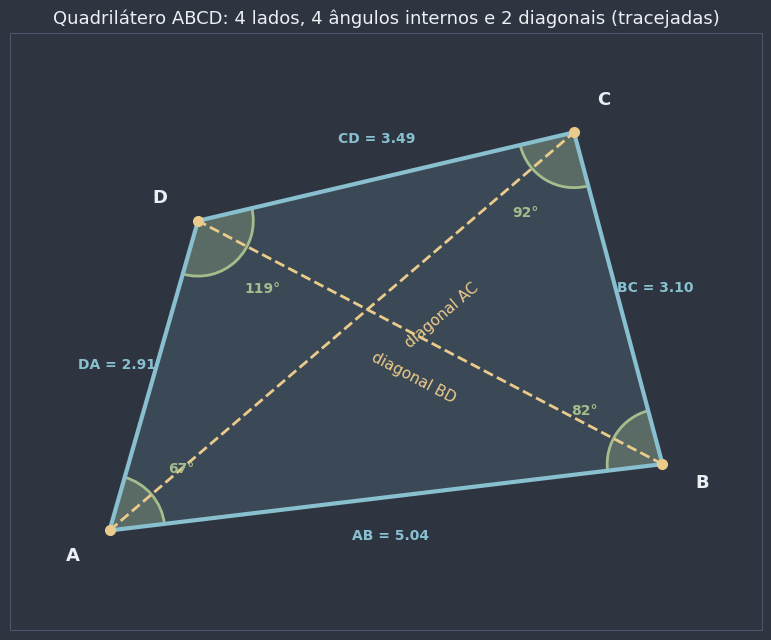

In [5]:
fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, quadrilatero, margem=0.9)
desenhar_quadrilatero(ax, quadrilatero, cor=COR_PONTO, largura=3)
for diagonal in diagonais:
    P, Q = ponto[diagonal[0]], ponto[diagonal[1]]
    ax.plot(*zip(P, Q), color=COR_AVISO, lw=2, linestyle="--")
ax.text(*(ponto_medio(A, C) + (0.55, -0.15)), "diagonal AC", color=COR_AVISO, fontsize=11,
        rotation=direcao_de(A, C))
ax.text(*(ponto_medio(B, D) + (-0.55, -0.55)), "diagonal BD", color=COR_AVISO, fontsize=11,
        rotation=direcao_de(D, B))
desenhar_angulos_internos(ax, quadrilatero, raio=0.5, raio_rotulo=0.85, tamanho_fonte=10)
centro = np.mean(quadrilatero, axis=0)
for k, lado in enumerate(lados):
    rotular_lado(ax, quadrilatero[k], quadrilatero[(k + 1) % 4], f"{lado} = {math.dist(*[ponto[c] for c in lado]):.2f}",
                 centro, cor=COR_PONTO, distancia=0.35)
rotular_vertices(ax, quadrilatero, distancia=0.4)
ax.set_title("Quadrilátero ABCD: 4 lados, 4 ângulos internos e 2 diagonais (tracejadas)", color=NORD_TEXTO,
             fontsize=13)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática — design de interfaces:** a tela em que você lê este notebook, cada janela, botão, cartão ou foto dentro dela é, formalmente, um quadrilátero (quase sempre um retângulo). Programas de desenho e de diagramação guardam essas formas exatamente como fizemos aqui: uma lista de quatro vértices, **em ordem**. Quando você "puxa o canto" de uma imagem para deformá-la em perspectiva, está movendo um desses quatro vértices.

### Convexo ou côncavo?

📌 **Definição formal (quadrilátero convexo e côncavo):** um quadrilátero é **convexo** quando, para quaisquer dois pontos do seu interior, o segmento que os liga fica **inteiro** dentro dele. Se isso falhar para algum par de pontos, ele é **côncavo**: tem uma "ponta afundada", um vértice cujo ângulo interno passa de 180°.

Neste curso vamos trabalhar quase sempre com quadriláteros **convexos**; a distinção volta, com mais detalhes, no notebook de Polígonos, mais adiante neste módulo.

**No código**, há um jeito simples de testar isso: ande pelos lados na ordem $A \to B \to C \to D \to A$ e observe para que lado você **vira** em cada vértice. Num quadrilátero convexo, você vira **sempre para o mesmo lado**; num côncavo, em um dos vértices você vira para o lado contrário. Quem diz para que lado se vira é a função `orientacao`, que é a mesma conta do teste de colinearidade de [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb), $(x_P - x_O)(y_Q - y_O) - (y_P - y_O)(x_Q - x_O)$, agora olhando também o **sinal**: zero quando os três pontos são colineares, positivo quando o caminho vira para a esquerda, negativo quando vira para a direita.

quadrilátero,"vira em A, B, C, D",ângulos internos,tipo_de_quadrilatero
convexo (o ABCD acima),esq. esq. esq. esq.,"67.2°, 81.9°, 91.7°, 119.2°",convexo
côncavo (a 'seta'),esq. esq. esq. dir.,"35.5°, 54.0°, 31.4°, 239.1°",côncavo


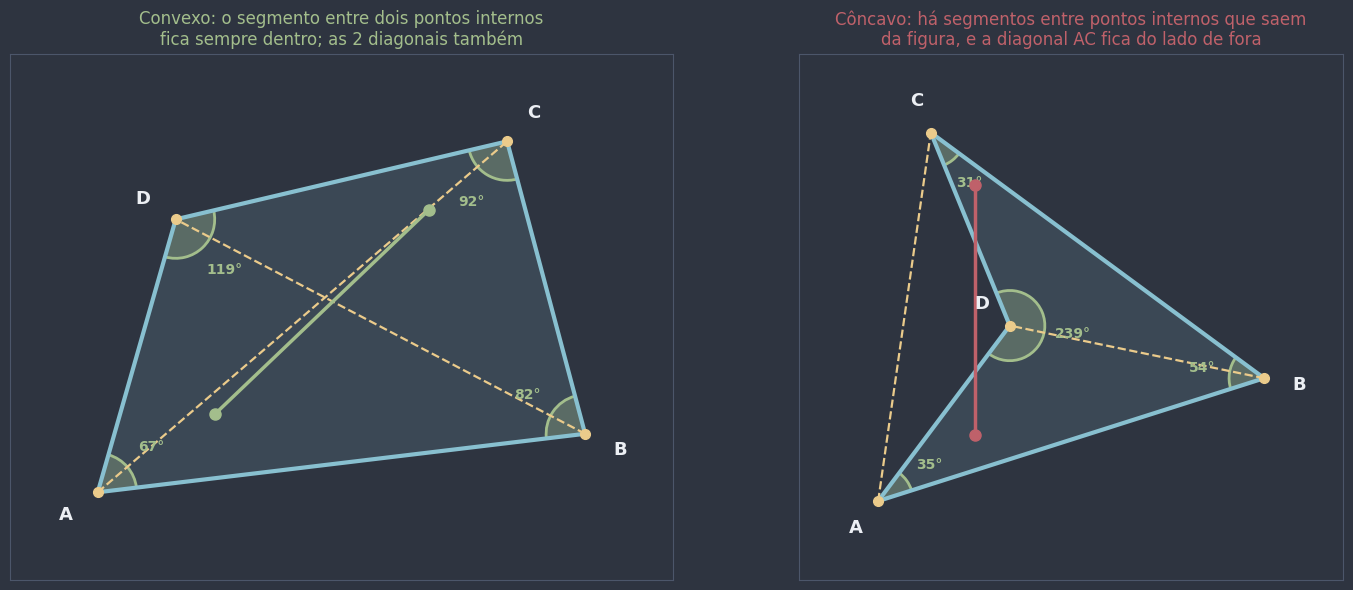

In [7]:
convexo = [A, B, C, D]
concavo = [np.array(p) for p in [(0.0, 0.0), (4.4, 1.4), (0.6, 4.2), (1.5, 2.0)]]

linhas = []
for nome_figura, vertices in [("convexo (o ABCD acima)", convexo), ("côncavo (a 'seta')", concavo)]:
    giros = [orientacao(vertices[k - 1], vertices[k], vertices[(k + 1) % 4]) for k in range(4)]
    linhas.append({
        "quadrilátero": nome_figura,
        "vira em A, B, C, D": "  ".join("esq." if g > 0 else "dir." for g in giros),
        "ângulos internos": ", ".join(f"{a:.1f}°" for a in angulos_internos(vertices)),
        "tipo_de_quadrilatero": tipo_de_quadrilatero(vertices),
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, vertices, titulo, cor, P1, P2 in [
    (ax1, convexo, "Convexo: o segmento entre dois pontos internos\nfica sempre dentro; as 2 diagonais também",
     COR_DESTAQUE, (1.2, 0.8), (3.4, 2.9)),
    (ax2, concavo, "Côncavo: há segmentos entre pontos internos que saem\nda figura, e a diagonal AC fica do lado de fora",
     COR_ALERTA, (1.1, 0.75), (1.1, 3.6)),
]:
    preparar_eixo(ax, vertices, margem=0.9)
    desenhar_quadrilatero(ax, vertices, cor=COR_PONTO, largura=3)
    desenhar_angulos_internos(ax, vertices, raio=0.4, raio_rotulo=0.72, tamanho_fonte=10)
    for i, j in ((0, 2), (1, 3)):
        ax.plot(*zip(vertices[i], vertices[j]), color=COR_AVISO, lw=1.6, linestyle="--")
    ax.plot(*zip(P1, P2), color=cor, lw=2.5)
    for P in (P1, P2):
        ax.plot(*P, "o", color=cor, markersize=8, zorder=6)
    rotular_vertices(ax, vertices, distancia=0.4)
    ax.set_title(titulo, color=cor, fontsize=12)
plt.tight_layout()
plt.show()

No quadrilátero côncavo, o vértice $D$ é a "ponta afundada": é ali que o caminho vira para o lado contrário, e é ali que o ângulo interno passa de 180°.

⚠️ **Erro comum:** ligar os pontos **fora de ordem**. Os mesmos quatro pontos, ligados em outra sequência, podem formar uma figura "cruzada", em forma de borboleta (ou de gravata-borboleta), em que dois lados se cruzam. Essa figura **não** é um quadrilátero simples, e nada do que vamos provar neste notebook vale para ela. Por isso a ordem das letras no nome $ABCD$ importa: ela diz em que sequência os vértices são ligados.

Veja os mesmos quatro pontos $A$, $B$, $C$ e $D$ do primeiro desenho, ligados em três ordens diferentes:

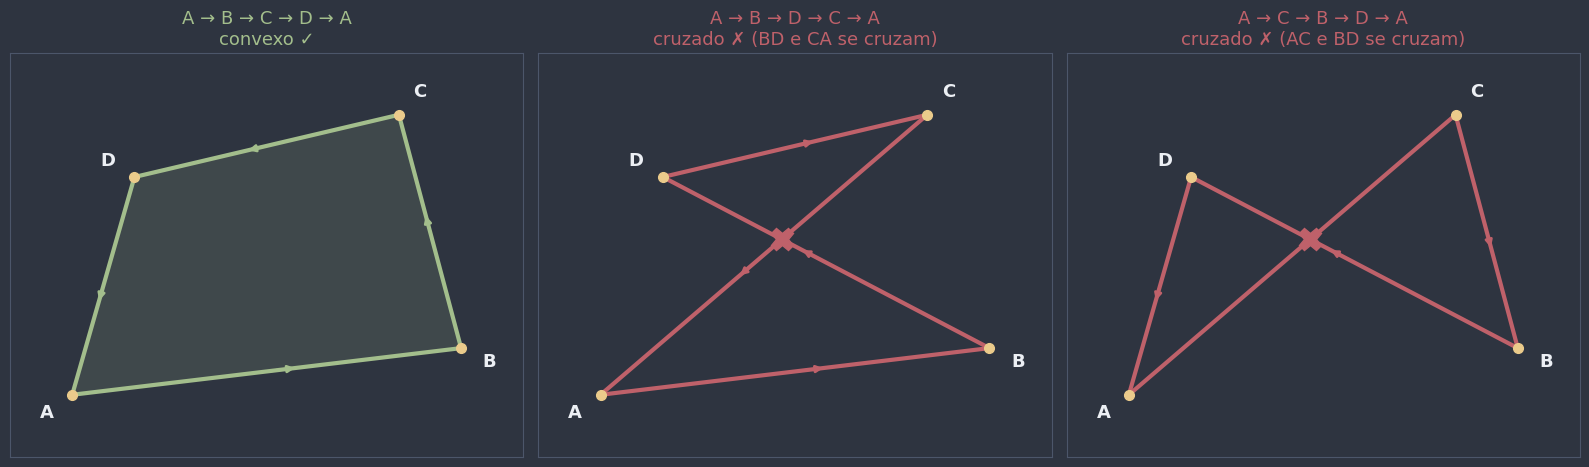

In [8]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 5.2))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, ordem in zip(eixos, ["ABCD", "ABDC", "ACBD"]):
    vertices = [ponto[letra] for letra in ordem]
    tipo = tipo_de_quadrilatero(vertices)
    simples = tipo != "cruzado"
    cor = COR_DESTAQUE if simples else COR_ALERTA
    preparar_eixo(ax, quadrilatero, margem=0.8)
    desenhar_quadrilatero(ax, vertices, cor=cor, largura=3, preencher=simples)
    for k in range(4):  # setinhas mostrando o sentido do caminho
        P, Q = vertices[k], vertices[(k + 1) % 4]
        ax.annotate("", xy=P + 0.58 * (Q - P), xytext=P + 0.5 * (Q - P),
                    arrowprops=dict(arrowstyle="-|>", color=cor, lw=2))
    if not simples:
        for k in range(2):  # procura os dois lados opostos que se cruzam e marca o cruzamento
            P1, P2, Q1, Q2 = vertices[k], vertices[k + 1], vertices[k + 2], vertices[(k + 3) % 4]
            if segmentos_se_cruzam(P1, P2, Q1, Q2):
                X = cruzamento(P1, direcao_de(P1, P2), Q1, direcao_de(Q1, Q2))
                ax.plot(*X, "X", color=COR_ALERTA, markersize=16, zorder=7)
                lados_cruzados = f"{ordem[k]}{ordem[k + 1]} e {ordem[k + 2]}{ordem[(k + 3) % 4]}"
    rotular_vertices(ax, quadrilatero, distancia=0.4)
    caminho = " → ".join(ordem) + f" → {ordem[0]}"
    resultado = f"{tipo} ✓" if simples else f"cruzado ✗ ({lados_cruzados} se cruzam)"
    ax.set_title(f"{caminho}\n{resultado}", color=cor, fontsize=13)
plt.tight_layout()
plt.show()

Com quatro pontos "bem espalhados" (nenhum dentro do triângulo formado pelos outros três), só **uma** das ordens forma um quadrilátero simples; as outras duas dão borboletas.

**Pergunta de checagem:** quantas diagonais tem um quadrilátero? E por que elas precisam ligar vértices **não consecutivos**?

**Pergunta de checagem:** no quadrilátero côncavo acima, uma das diagonais ficou do lado de fora da figura. Isso pode acontecer num quadrilátero convexo? Por quê?

## 2. Soma dos ângulos internos de um quadrilátero

Num triângulo, os três ângulos internos somam sempre 180° (você conferiu em [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) e demonstrou em [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb)). E num quadrilátero? A escora do portão já deu a dica: **uma diagonal divide o quadrilátero em dois triângulos**.

📌 **Teorema (soma dos ângulos internos do quadrilátero):** em todo quadrilátero convexo $ABCD$,

$$\hat{A} + \hat{B} + \hat{C} + \hat{D} = 360^\circ.$$

Trace a diagonal $\overline{AC}$. Ela divide o ângulo $\hat{A}$ em duas partes, $\hat{A}_1$ (do lado de $B$) e $\hat{A}_2$ (do lado de $D$), e o ângulo $\hat{C}$ em $\hat{C}_1$ e $\hat{C}_2$, do mesmo jeito.

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | a diagonal $\overline{AC}$ divide $ABCD$ nos triângulos $ABC$ e $ACD$ | $ABCD$ é convexo, então $\overline{AC}$ fica dentro dele |
| 2 | $\hat{A} = \hat{A}_1 + \hat{A}_2$ e $\hat{C} = \hat{C}_1 + \hat{C}_2$ | $\overline{AC}$ divide os ângulos em $A$ e em $C$ em dois ângulos adjacentes (0403a) |
| 3 | $\hat{A}_1 + \hat{B} + \hat{C}_1 = 180^\circ$ | soma dos ângulos internos do triângulo $ABC$ (0406a) |
| 4 | $\hat{A}_2 + \hat{C}_2 + \hat{D} = 180^\circ$ | soma dos ângulos internos do triângulo $ACD$ (0406a) |
| 5 | $\hat{A} + \hat{B} + \hat{C} + \hat{D} = 360^\circ$ | somando 3 e 4 e reagrupando com 2 ∎ |

**A representação numérica.** Vamos medir, com o transferidor digital, os ângulos dos dois triângulos formados pela diagonal $\overline{AC}$ no quadrilátero da seção 1, e conferir que as peças se encaixam.

In [9]:
A, B, C, D = quadrilatero
pedacos = {
    "A₁ (em ABC)": medir_angulo(A, B, C), "B (em ABC)": medir_angulo(B, A, C), "C₁ (em ABC)": medir_angulo(C, A, B),
    "A₂ (em ACD)": medir_angulo(A, C, D), "C₂ (em ACD)": medir_angulo(C, A, D), "D (em ACD)": medir_angulo(D, A, C),
}
tabela_triangulos = pd.DataFrame([
    {"triângulo": "ABC", "ângulos": "A₁, B, C₁",
     "medidas": ", ".join(f"{pedacos[k]:.1f}°" for k in ["A₁ (em ABC)", "B (em ABC)", "C₁ (em ABC)"]),
     "soma": f"{pedacos['A₁ (em ABC)'] + pedacos['B (em ABC)'] + pedacos['C₁ (em ABC)']:.1f}°"},
    {"triângulo": "ACD", "ângulos": "A₂, C₂, D",
     "medidas": ", ".join(f"{pedacos[k]:.1f}°" for k in ["A₂ (em ACD)", "C₂ (em ACD)", "D (em ACD)"]),
     "soma": f"{pedacos['A₂ (em ACD)'] + pedacos['C₂ (em ACD)'] + pedacos['D (em ACD)']:.1f}°"},
])
display(tabela_triangulos.style.hide(axis="index"))

angulos = angulos_internos(quadrilatero)
montagem = pd.DataFrame([
    {"ângulo do quadrilátero": "A", "montado com as peças": f"A₁ + A₂ = {pedacos['A₁ (em ABC)'] + pedacos['A₂ (em ACD)']:.1f}°",
     "medido direto": f"{angulos[0]:.1f}°"},
    {"ângulo do quadrilátero": "B", "montado com as peças": f"B = {pedacos['B (em ABC)']:.1f}°", "medido direto": f"{angulos[1]:.1f}°"},
    {"ângulo do quadrilátero": "C", "montado com as peças": f"C₁ + C₂ = {pedacos['C₁ (em ABC)'] + pedacos['C₂ (em ACD)']:.1f}°",
     "medido direto": f"{angulos[2]:.1f}°"},
    {"ângulo do quadrilátero": "D", "montado com as peças": f"D = {pedacos['D (em ACD)']:.1f}°", "medido direto": f"{angulos[3]:.1f}°"},
])
display(montagem.style.hide(axis="index"))
print(f"Â + B̂ + Ĉ + D̂ = {' + '.join(f'{a:.1f}' for a in angulos)} = {sum(angulos):.1f}°  (= 180° + 180°)")

triângulo,ângulos,medidas,soma
ABC,"A₁, B, C₁","33.8°, 81.9°, 64.3°",180.0°
ACD,"A₂, C₂, D","33.5°, 27.4°, 119.2°",180.0°


ângulo do quadrilátero,montado com as peças,medido direto
A,A₁ + A₂ = 67.2°,67.2°
B,B = 81.9°,81.9°
C,C₁ + C₂ = 91.7°,91.7°
D,D = 119.2°,119.2°


Â + B̂ + Ĉ + D̂ = 67.2 + 81.9 + 91.7 + 119.2 = 360.0°  (= 180° + 180°)


A representação gráfica da demonstração: cada triângulo com sua cor, e cada pedaço de ângulo pintado da cor do triângulo a que pertence.

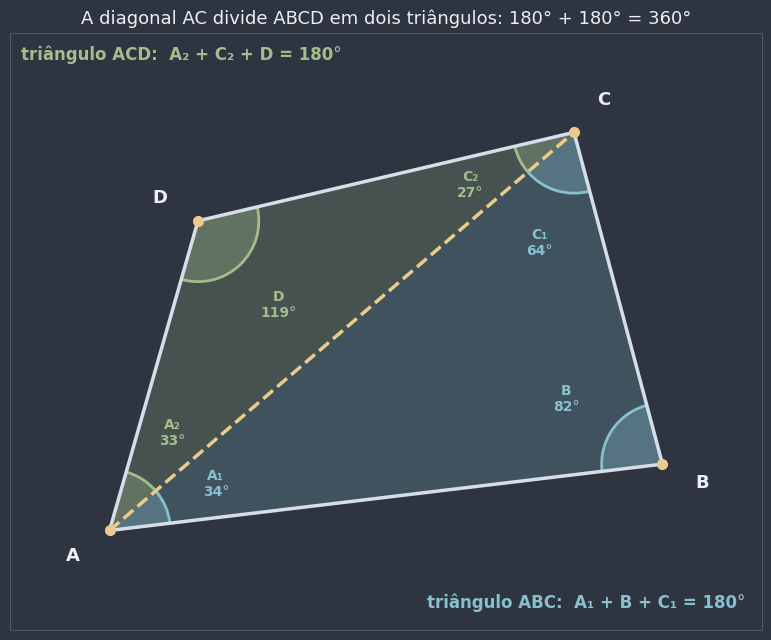

In [10]:
fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, quadrilatero, margem=0.9)
ax.add_patch(Polygon([A, B, C], closed=True, facecolor=COR_PONTO, alpha=0.22, edgecolor="none"))
ax.add_patch(Polygon([A, C, D], closed=True, facecolor=COR_DESTAQUE, alpha=0.22, edgecolor="none"))
desenhar_quadrilatero(ax, quadrilatero, cor=NORD_TEXTO_SEC, largura=2.5, preencher=False)
ax.plot(*zip(A, C), color=COR_AVISO, lw=2.5, linestyle="--")
for vertice, p, q, cor, nome in [
    (A, B, C, COR_PONTO, "A₁"), (B, C, A, COR_PONTO, "B"), (C, A, B, COR_PONTO, "C₁"),
    (A, C, D, COR_DESTAQUE, "A₂"), (C, D, A, COR_DESTAQUE, "C₂"), (D, A, C, COR_DESTAQUE, "D"),
]:
    desenhar_arco(ax, vertice, p, q, raio=0.55, cor=cor, rotulo=f"{nome}\n{medir_angulo(vertice, p, q):.0f}°",
                  raio_rotulo=1.05, tamanho_fonte=10)
ax.text(-0.8, 4.25, "triângulo ACD:  A₂ + C₂ + D = 180°", color=COR_DESTAQUE, fontsize=12, fontweight="bold")
ax.text(5.75, -0.7, "triângulo ABC:  A₁ + B + C₁ = 180°", color=COR_PONTO, fontsize=12, ha="right",
        fontweight="bold")
rotular_vertices(ax, quadrilatero, distancia=0.4)
ax.set_title("A diagonal AC divide ABCD em dois triângulos: 180° + 180° = 360°", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

Um exemplo só não prova nada, mas a demonstração acima vale para **qualquer** quadrilátero convexo. Para ganhar confiança, vamos sortear vários quadriláteros (descartando as borboletas, que não são simples) e somar os ângulos de cada um.

In [11]:
gerador = np.random.default_rng(2026)
linhas = []
while len(linhas) < 8:
    vertices = [np.round(gerador.uniform(0, 6, 2), 1) for _ in range(4)]
    tipo = tipo_de_quadrilatero(vertices)
    if tipo in ("cruzado", "degenerado"):
        continue  # não é um quadrilátero simples: sorteia de novo
    angulos = angulos_internos(vertices)
    linhas.append({
        "vértices A, B, C, D": "  ".join(f"({v[0]:g}, {v[1]:g})" for v in vertices),
        "tipo": tipo,
        "ângulos internos": ", ".join(f"{a:.1f}°" for a in angulos),
        "soma": f"{sum(angulos):.1f}°",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

"vértices A, B, C, D",tipo,ângulos internos,soma
"(3.9, 1.8) (5.8, 5.5) (3.8, 4.5) (3.1, 5)",côncavo,"41.2°, 36.3°, 242.1°, 40.4°",360.0°
"(2.7, 2) (1.7, 1.4) (3.2, 2.6) (4, 0.1)",côncavo,"266.6°, 7.7°, 69.1°, 16.6°",360.0°
"(4.8, 3.6) (2.1, 5.7) (3.4, 2.6) (5.4, 1.9)",convexo,"147.3°, 29.4°, 132.0°, 51.3°",360.0°
"(4.2, 1.9) (1.6, 4.2) (1.4, 3) (3.5, 1.1)",convexo,"90.3°, 58.0°, 122.7°, 89.0°",360.0°
"(4.4, 3.3) (3.7, 2.2) (2.5, 3) (2.8, 4.1)",convexo,"84.1°, 88.8°, 108.4°, 78.7°",360.0°
"(3.5, 2.5) (0, 4.8) (3.1, 2) (3, 0.6)",côncavo,"108.6°, 8.8°, 232.0°, 10.7°",360.0°
"(5.4, 5.9) (0.4, 2.1) (4.4, 1.9) (3.4, 2.5)",côncavo,"22.3°, 40.1°, 28.1°, 269.5°",360.0°
"(3.3, 5.5) (1.4, 3.6) (4.9, 0.8) (3.7, 2.4)",côncavo,"52.4°, 83.7°, 14.5°, 209.5°",360.0°


Todas as somas deram 360°, inclusive nos quadriláteros **côncavos** que apareceram no sorteio.

💡 **Dica — e o quadrilátero côncavo?** A demonstração usou uma diagonal que fica **dentro** da figura. No côncavo, uma das diagonais fica do lado de fora (você viu na seção 1), mas a **outra**, a que sai da ponta afundada, fica dentro e divide a figura em dois triângulos do mesmo jeito. Por isso a soma também é 360°, desde que o ângulo da ponta afundada seja contado como o ângulo **interno**, maior que 180°.

🕹️ **Widget interativo:** os sliders `x de C` e `y de C` movem o vértice $C$; os outros três ficam parados. A figura mostra a diagonal usada para dividir o quadrilátero em dois triângulos (o código escolhe sozinho a que fica dentro dele) e os quatro ângulos internos, com a soma no título. Tente:
- deixar o quadrilátero bem "achatado" ou bem "esticado": a soma muda?
- levar $C$ para dentro do triângulo $ABD$ (por exemplo, $x = 1{,}5$ e $y = 1{,}5$): o quadrilátero fica côncavo;
- levar $C$ para baixo do lado $\overline{AB}$ (por exemplo, $y = -1$): a figura vira uma borboleta, e não é mais um quadrilátero simples.

In [ ]:
def explorar_soma(x_C: float, y_C: float) -> None:
    A, B, D = np.array([0.0, 0.0]), np.array([5.0, 0.0]), np.array([0.5, 3.5])
    C = np.array([x_C, y_C])
    vertices = [A, B, C, D]
    tipo = tipo_de_quadrilatero(vertices)
    fig, ax = plt.subplots(figsize=(9, 6.6))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-1.3, -1.7), (7.7, 6.2)], margem=0)
    if tipo in ("cruzado", "degenerado"):
        desenhar_quadrilatero(ax, vertices, cor=COR_ALERTA, largura=3, preencher=False)
        rotular_vertices(ax, vertices, distancia=0.4)
        motivo = "dois lados se cruzam" if tipo == "cruzado" else "três vértices consecutivos estão alinhados"
        ax.set_title(f"Não é um quadrilátero simples: {motivo}.\nMova C de volta.", color=COR_ALERTA, fontsize=13)
    else:
        # A diagonal AC fica dentro da figura quando B e D estão em lados opostos da reta AC;
        # se não, quem fica dentro é a diagonal BD.
        if orientacao(A, C, B) * orientacao(A, C, D) < 0:
            triangulos, diagonal = ([A, B, C], [A, C, D]), (A, C)
        else:
            triangulos, diagonal = ([A, B, D], [B, C, D]), (B, D)
        for triangulo, cor in zip(triangulos, (COR_PONTO, COR_DESTAQUE)):
            ax.add_patch(Polygon(triangulo, closed=True, facecolor=cor, alpha=0.22, edgecolor="none"))
        desenhar_quadrilatero(ax, vertices, cor=NORD_TEXTO_SEC, largura=2.5, preencher=False)
        ax.plot(*zip(*diagonal), color=COR_AVISO, lw=2.2, linestyle="--")
        angulos = desenhar_angulos_internos(ax, vertices, raio=0.45, cores=[COR_AVISO] * 4, tamanho_fonte=10)
        rotular_vertices(ax, vertices, distancia=0.4)
        nome_diagonal = "AC" if diagonal[0] is A else "BD"
        ax.set_title(f"{tipo}, dividido pela diagonal {nome_diagonal}\n"
                     f"{' + '.join(f'{a:.1f}°' for a in angulos)} = {sum(angulos):.1f}°",
                     color=COR_DESTAQUE, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_soma,
    x_C=widgets.FloatSlider(value=4.5, min=-1, max=7, step=0.25, description="x de C:"),
    y_C=widgets.FloatSlider(value=3.5, min=-1.5, max=6, step=0.25, description="y de C:"),
);

interactive(children=(FloatSlider(value=4.5, description='x de C:', max=7.0, min=-1.0, step=0.25), FloatSlider…

🎯 **Aplicação prática — conferindo a planta de um cômodo:** um cômodo "retangular" deveria ter quatro cantos de 90°. Quando um pedreiro ou arquiteto mede os quatro cantos de um cômodo com um transferidor (ou com uma trena, usando o triângulo 3-4-5), a soma **tem** que dar 360°. Se não der, alguma medida está errada. Mas atenção ao sentido da conclusão: soma diferente de 360° **garante** erro; soma igual a 360° **não garante** que está tudo certo (um cômodo torto, com cantos de 88°, 92°, 87° e 93°, também soma 360°).

In [13]:
def conferir_planta(cantos: list[float]) -> str:
    """Diagnóstico das medidas dos 4 cantos de um cômodo, usando a soma dos ângulos internos."""
    soma = sum(cantos)
    if not math.isclose(soma, 360, abs_tol=1e-9):
        return f"❌ soma {soma:g}°: alguma medida está errada (deveria ser 360°)"
    if all(math.isclose(c, 90) for c in cantos):
        return "✅ soma 360° e quatro cantos retos: cômodo no esquadro"
    return "⚠️ soma 360°: as medidas são possíveis, mas o cômodo está fora do esquadro"


comodos = {
    "sala": [90, 90, 90, 90],
    "quarto": [89.5, 90.5, 91, 90],
    "cozinha": [88, 92, 87, 93],
    "banheiro": [90, 90, 90, 85],
}
display(pd.DataFrame([
    {"cômodo": nome, "cantos medidos": ", ".join(f"{c:g}°" for c in cantos), "diagnóstico": conferir_planta(cantos)}
    for nome, cantos in comodos.items()
]).style.hide(axis="index"))

cômodo,cantos medidos,diagnóstico
sala,"90°, 90°, 90°, 90°",✅ soma 360° e quatro cantos retos: cômodo no esquadro
quarto,"89.5°, 90.5°, 91°, 90°",❌ soma 361°: alguma medida está errada (deveria ser 360°)
cozinha,"88°, 92°, 87°, 93°","⚠️ soma 360°: as medidas são possíveis, mas o cômodo está fora do esquadro"
banheiro,"90°, 90°, 90°, 85°",❌ soma 355°: alguma medida está errada (deveria ser 360°)


📎 **Conexão:** a técnica de "dividir em triângulos a partir de uma diagonal" vai ser generalizada no notebook de Polígonos, mais adiante neste módulo: traçando todas as diagonais que saem de **um** vértice, um polígono de $n$ lados se divide em $n - 2$ triângulos, e a soma dos seus ângulos internos é $(n - 2) \cdot 180^\circ$. Para o quadrilátero, $n = 4$: $2 \cdot 180^\circ = 360^\circ$.

**Pergunta de checagem:** se um quadrilátero tem três ângulos medindo 80°, 95° e 120°, quanto mede o quarto?

**Pergunta de checagem:** um quadrilátero pode ter os quatro ângulos internos agudos (menores que 90°)? E os quatro obtusos? Justifique usando a soma de 360°.

## 3. Quadriláteros notáveis: o mapa geral

Alguns quadriláteros aparecem tanto que ganharam nome próprio. Antes de estudar cada um, vale ter o **mapa** completo na cabeça, porque eles se encaixam uns dentro dos outros, como bonecas russas:

- **Trapézio:** quadrilátero com **pelo menos um** par de lados opostos paralelos. É o assunto das seções 4 e 5.
- **Paralelogramo:** quadrilátero com os **dois** pares de lados opostos paralelos.
- **Retângulo:** paralelogramo com os quatro ângulos **retos**.
- **Losango:** paralelogramo com os quatro lados **congruentes**.
- **Quadrado:** paralelogramo que é, ao mesmo tempo, retângulo **e** losango: quatro ângulos retos e quatro lados congruentes.

Repare na palavra "pelo menos" na definição de trapézio. Se um quadrilátero tem os dois pares de lados opostos paralelos, ele certamente tem **pelo menos um**. Então:

> **neste curso, todo paralelogramo também é um trapézio**, um trapézio especial, com os dois pares de lados paralelos.

É a mesma lógica que você já conhece de outros lugares: todo quadrado é um retângulo (tem quatro ângulos retos) e também um losango (tem quatro lados iguais); todo triângulo equilátero é isósceles ([`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb)).

🕵️ **Curiosidade histórica:** nem todo mundo concorda com essa convenção. Alguns livros definem trapézio como o quadrilátero com **exatamente um** par de lados paralelos (a convenção **exclusiva**); nesses livros, paralelogramo **não** é trapézio. Outros usam "pelo menos um par" (a convenção **inclusiva**, a nossa). A confusão é antiga e chega até os nomes: em inglês, o mesmo quadrilátero com um par de lados paralelos se chama *trapezium* no Reino Unido e *trapezoid* nos Estados Unidos, e cada uma dessas palavras significa outra coisa no outro país! A convenção inclusiva tem uma vantagem prática: tudo o que for provado para trapézios vale automaticamente para paralelogramos, retângulos, losangos e quadrados, sem precisar repetir a demonstração.

A representação gráfica do mapa é um diagrama de conjuntos (como os de [`0102a_conjuntos.ipynb`](../01_conjuntos_e_funcoes/0102a_conjuntos.ipynb)): cada conjunto está **contido** no anterior.

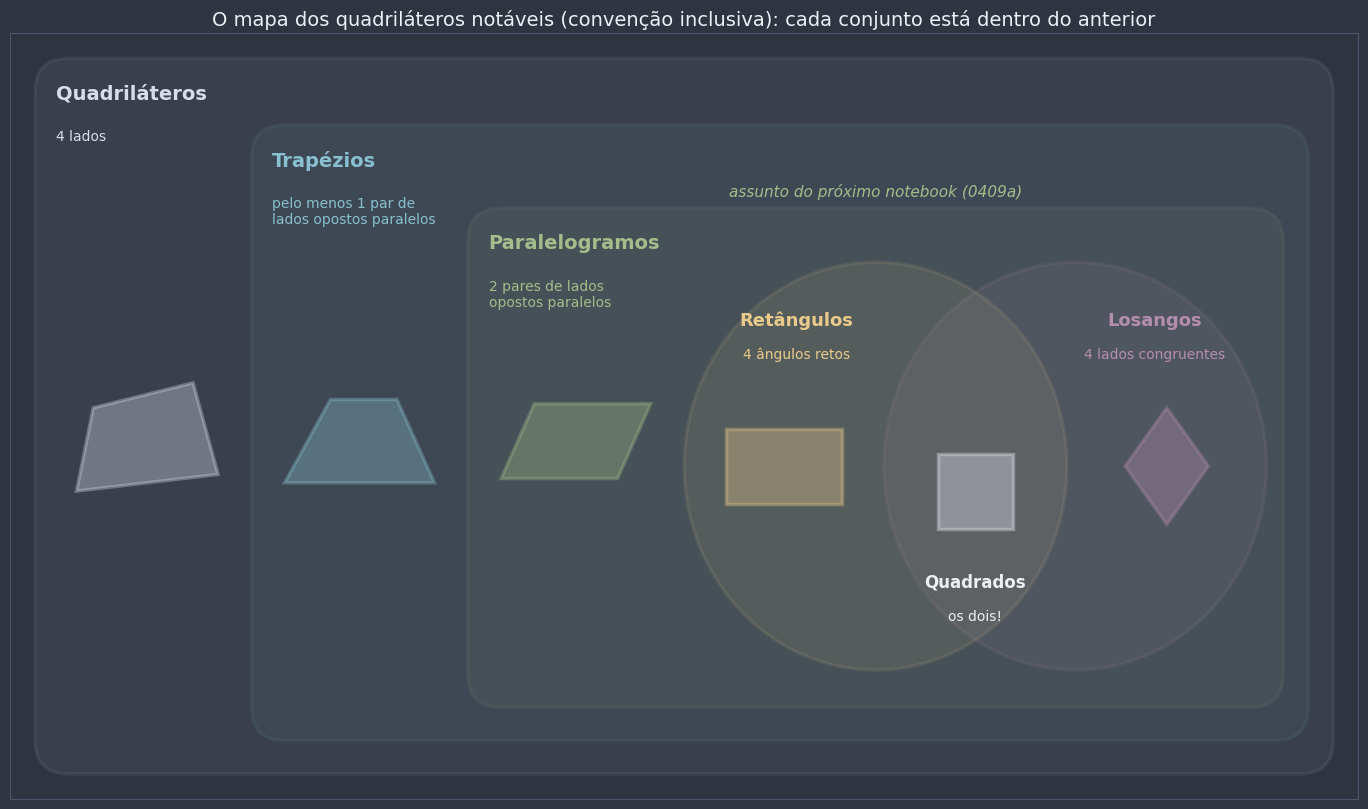

In [14]:
def icone(ax, centro, forma, cor, escala: float = 1.0) -> None:
    """Desenha uma figurinha (lista de vértices em torno de (0, 0)) centrada em `centro`."""
    vertices = [np.asarray(centro) + escala * np.asarray(v) for v in forma]
    ax.add_patch(Polygon(vertices, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2.5, zorder=4))


FORMAS = {
    "qualquer": [(-0.8, -0.6), (0.9, -0.4), (0.6, 0.7), (-0.6, 0.4)],
    "trapézio": [(-0.9, -0.5), (0.9, -0.5), (0.45, 0.5), (-0.35, 0.5)],
    "paralelogramo": [(-0.9, -0.45), (0.5, -0.45), (0.9, 0.45), (-0.5, 0.45)],
    "retângulo": [(-0.7, -0.45), (0.7, -0.45), (0.7, 0.45), (-0.7, 0.45)],
    "losango": [(0, -0.7), (0.5, 0), (0, 0.7), (-0.5, 0)],
    "quadrado": [(-0.45, -0.45), (0.45, -0.45), (0.45, 0.45), (-0.45, 0.45)],
}

fig, ax = plt.subplots(figsize=(15, 8.2))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(0, 0), (16, 9)], margem=0.1)
caixas = [  # (x0, y0, largura, altura, cor, nome, descrição, posição do ícone, forma do ícone)
    (0.2, 0.2, 15.6, 8.6, NORD_TEXTO_SEC, "Quadriláteros", "4 lados", (1.5, 4.2), "qualquer"),
    (2.8, 0.6, 12.7, 7.4, COR_PONTO, "Trapézios", "pelo menos 1 par de\nlados opostos paralelos", (4.1, 4.2), "trapézio"),
    (5.4, 1.0, 9.8, 6.0, COR_DESTAQUE, "Paralelogramos", "2 pares de lados\nopostos paralelos", (6.7, 4.2), "paralelogramo"),
]
for x0, y0, largura, altura, cor, nome, descricao, posicao_icone, forma in caixas:
    ax.add_patch(FancyBboxPatch((x0, y0), largura, altura, boxstyle="round,pad=0,rounding_size=0.4",
                                facecolor=cor, alpha=0.07, edgecolor=cor, lw=2.5))
    ax.text(x0 + 0.25, y0 + altura - 0.3, nome, color=cor, fontsize=14, fontweight="bold", va="top")
    ax.text(x0 + 0.25, y0 + altura - 0.85, descricao, color=cor, fontsize=10, va="top")
    icone(ax, posicao_icone, FORMAS[forma], cor)

for centro, cor in [((10.3, 3.9), COR_AVISO), ((12.7, 3.9), COR_EXTRA)]:
    ax.add_patch(Ellipse(centro, 4.6, 4.9, facecolor=cor, alpha=0.1, edgecolor=cor, lw=2.5))
ax.text(9.35, 5.6, "Retângulos", color=COR_AVISO, fontsize=13, fontweight="bold", ha="center")
ax.text(9.35, 5.2, "4 ângulos retos", color=COR_AVISO, fontsize=10, ha="center")
icone(ax, (9.2, 3.9), FORMAS["retângulo"], COR_AVISO)
ax.text(13.65, 5.6, "Losangos", color=COR_EXTRA, fontsize=13, fontweight="bold", ha="center")
ax.text(13.65, 5.2, "4 lados congruentes", color=COR_EXTRA, fontsize=10, ha="center")
icone(ax, (13.8, 3.9), FORMAS["losango"], COR_EXTRA)
ax.text(11.5, 2.45, "Quadrados", color=NORD_TEXTO, fontsize=12, fontweight="bold", ha="center")
ax.text(11.5, 2.05, "os dois!", color=NORD_TEXTO, fontsize=10, ha="center")
icone(ax, (11.5, 3.6), FORMAS["quadrado"], NORD_TEXTO)
ax.text(10.3, 7.15, "assunto do próximo notebook (0409a)", color=COR_DESTAQUE, fontsize=11, ha="center",
        style="italic")
ax.set_title("O mapa dos quadriláteros notáveis (convenção inclusiva): cada conjunto está dentro do anterior",
             color=NORD_TEXTO, fontsize=14)
plt.tight_layout()
plt.show()

Agora a representação numérica. A função `classificar_quadrilatero` testa, num quadrilátero convexo, **cada** nome do mapa: conta quantos pares de lados opostos são paralelos (com a função `sao_paralelos`, que compara as inclinações a menos de 180°, como em [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb)), mede os lados e os ângulos. Como a convenção é inclusiva, um mesmo quadrilátero pode receber **vários** ✅. A última coluna mostra o nome **mais específico**, o que se usa no dia a dia.

In [15]:
def classificar_quadrilatero(vertices) -> dict[str, bool | int]:
    """Testa, num quadrilátero convexo ABCD, cada nome do mapa (convenção inclusiva)."""
    A, B, C, D = vertices
    pares_paralelos = int(sao_paralelos(A, B, D, C)) + int(sao_paralelos(B, C, A, D))
    lados = [math.dist(vertices[k], vertices[(k + 1) % 4]) for k in range(4)]
    paralelogramo = pares_paralelos == 2
    retangulo = paralelogramo and all(math.isclose(a, 90, abs_tol=1e-6) for a in angulos_internos(vertices))
    losango = paralelogramo and all(math.isclose(lado, lados[0]) for lado in lados)
    return {
        "pares paralelos": pares_paralelos,
        "trapézio": pares_paralelos >= 1,
        "paralelogramo": paralelogramo,
        "retângulo": retangulo,
        "losango": losango,
        "quadrado": retangulo and losango,
    }


def nome_mais_especifico(vertices) -> str:
    """O nome mais 'apertado' do mapa que serve para o quadrilátero."""
    testes = classificar_quadrilatero(vertices)
    for nome in ("quadrado", "retângulo", "losango", "paralelogramo", "trapézio"):
        if testes[nome]:
            return nome
    return "quadrilátero qualquer"


altura_losango = 4 * math.sin(math.radians(60))
GALERIA = {
    "Q1": [(0, 0), (3, 0), (3, 3), (0, 3)],
    "Q2": [(0, 0), (5, 0), (5, 3), (0, 3)],
    "Q3": [(0, 0), (4, 0), (6, altura_losango), (2, altura_losango)],
    "Q4": [(0, 0), (5, 0), (6.5, 3), (1.5, 3)],
    "Q5": [(0, 0), (6, 0), (4.5, 3), (1.5, 3)],
    "Q6": [(0, 0), (6, 0), (3.5, 3), (0, 3)],
    "Q7": [(0, 0), (7, 0), (5, 3), (1, 3)],
    "Q8": [(0, 0), (5, 0.8), (4, 3.5), (0.8, 2.6)],
}
GALERIA = {nome: [np.array(v, dtype=float) for v in vertices] for nome, vertices in GALERIA.items()}

linhas = []
for nome, vertices in GALERIA.items():
    testes = classificar_quadrilatero(vertices)
    linha = {"figura": nome, "pares paralelos": testes["pares paralelos"]}
    linha.update({chave: "✅" if testes[chave] else "❌"
                  for chave in ("trapézio", "paralelogramo", "retângulo", "losango", "quadrado")})
    linha["nome mais específico"] = nome_mais_especifico(vertices)
    linhas.append(linha)
display(pd.DataFrame(linhas).style.hide(axis="index"))

figura,pares paralelos,trapézio,paralelogramo,retângulo,losango,quadrado,nome mais específico
Q1,2,✅,✅,✅,✅,✅,quadrado
Q2,2,✅,✅,✅,❌,❌,retângulo
Q3,2,✅,✅,❌,✅,❌,losango
Q4,2,✅,✅,❌,❌,❌,paralelogramo
Q5,1,✅,❌,❌,❌,❌,trapézio
Q6,1,✅,❌,❌,❌,❌,trapézio
Q7,1,✅,❌,❌,❌,❌,trapézio
Q8,0,❌,❌,❌,❌,❌,quadrilátero qualquer


Leia a tabela de baixo para cima: cada linha tem **menos** ✅ que a de cima. O quadrado (Q1) ganha todos; o quadrilátero qualquer (Q8), nenhum. E repare que **todas** as figuras de Q1 a Q7 são trapézios.

Nos desenhos, os lados opostos paralelos aparecem com a **mesma cor**: verde para o par $\overline{AB}$ e $\overline{DC}$, amarelo para o par $\overline{BC}$ e $\overline{AD}$; lados sem par paralelo ficam cinza.

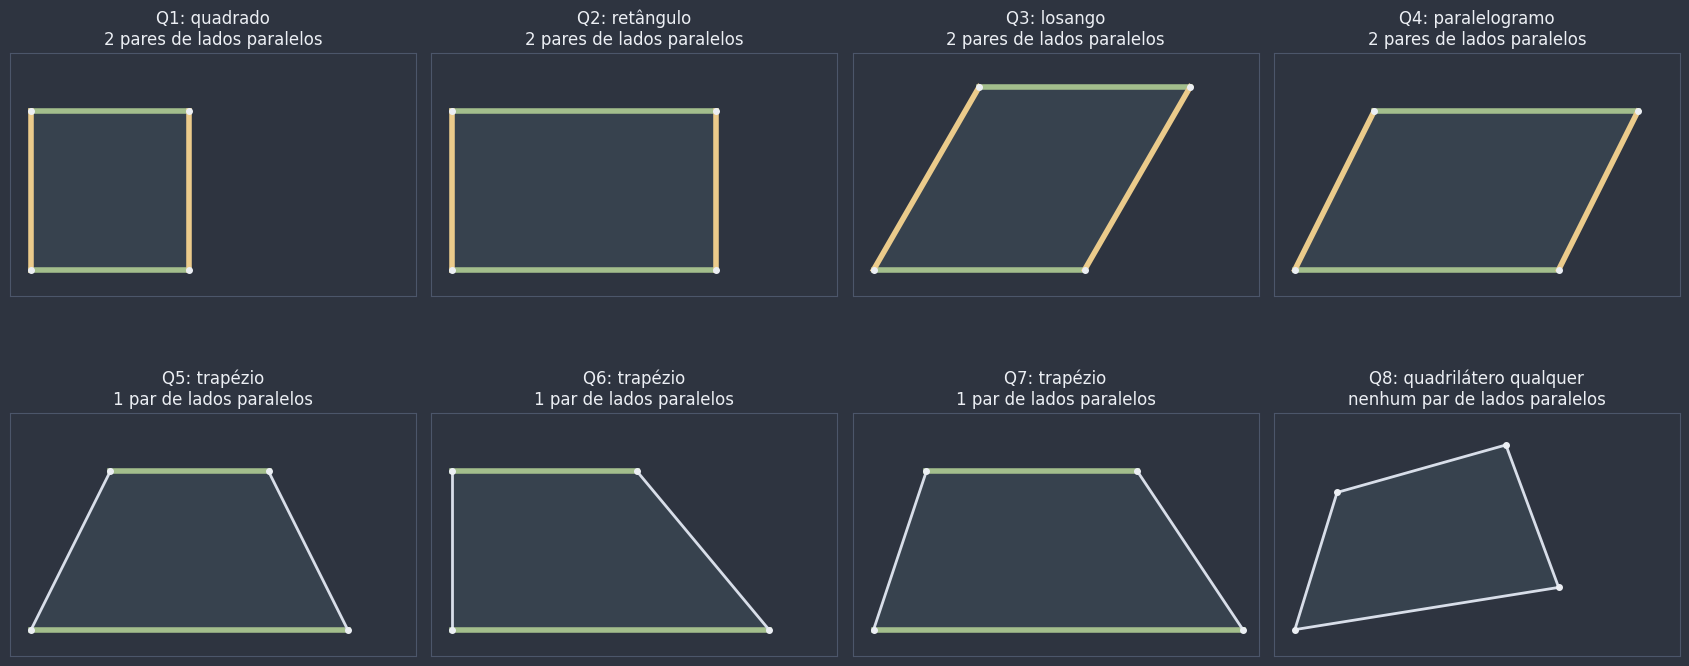

In [16]:
fig, eixos = plt.subplots(2, 4, figsize=(17, 8))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (nome, vertices) in zip(eixos.flat, GALERIA.items()):
    A, B, C, D = vertices
    preparar_eixo(ax, [(-0.3, -0.4), (7.2, 4.0)], margem=0.1)
    ax.add_patch(Polygon(vertices, closed=True, facecolor=COR_PONTO, alpha=0.1, edgecolor="none"))
    pares = [((A, B), (D, C), COR_DESTAQUE), ((B, C), (A, D), COR_AVISO)]
    for lado_1, lado_2, cor in pares:
        paralelos = sao_paralelos(*lado_1, *lado_2)
        for P, Q in (lado_1, lado_2):
            ax.plot(*zip(P, Q), color=cor if paralelos else NORD_TEXTO_SEC, lw=4 if paralelos else 2)
    for vertice in vertices:
        ax.plot(*vertice, "o", color=NORD_TEXTO, markersize=4)
    pares_paralelos = classificar_quadrilatero(vertices)["pares paralelos"]
    texto_pares = {0: "nenhum par", 1: "1 par", 2: "2 pares"}[pares_paralelos] + " de lados paralelos"
    ax.set_title(f"{nome}: {nome_mais_especifico(vertices)}\n{texto_pares}", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

📎 **Conexão:** este notebook e o próximo, 📌 Paralelogramos e Casos Particulares, formam um **par**. Aqui você monta o mapa e estuda o primeiro nível dele, o trapézio; lá, o estudo desce para os paralelogramos e seus casos particulares (retângulo, losango e quadrado). Por isso, guarde bem o diagrama acima antes de seguir.

📖 **Leitura complementar:** [Quadrilátero](https://pt.wikipedia.org/wiki/Quadril%C3%A1tero) (definição geral e classificação)

**Pergunta de checagem:** um paralelogramo pode ser chamado de trapézio, segundo a convenção adotada no curso? Por quê?

**Pergunta de checagem:** verdadeiro ou falso: "todo retângulo é um trapézio" e "todo trapézio é um retângulo"?

## 4. Trapézios: elementos e propriedades

📌 **Definição formal (trapézio):** **trapézio** é um quadrilátero que tem **pelo menos um** par de lados opostos paralelos. Esses dois lados paralelos são as **bases** do trapézio.

Vamos sempre chamar o trapézio de $ABCD$ com $\overline{AB} \parallel \overline{DC}$, e com $\overline{AB}$ embaixo. Seus elementos:

| Elemento | No trapézio $ABCD$ |
|---|---|
| **base maior** ($B$) e **base menor** ($b$) | os dois lados paralelos, $\overline{AB}$ e $\overline{DC}$ |
| **lados não paralelos** (ou **laterais**) | $\overline{AD}$ e $\overline{BC}$ |
| **altura** ($h$) | a distância entre as retas das duas bases |
| ângulos das bases | $\hat{A}$ e $\hat{B}$ (na base maior); $\hat{C}$ e $\hat{D}$ (na base menor) |

A **altura** é uma velha conhecida: em [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) você viu que todos os pontos de uma reta estão à mesma distância de uma paralela a ela. Então a altura pode ser medida em **qualquer** lugar entre as bases, sempre na perpendicular.

Conforme os lados não paralelos, o trapézio recebe um sobrenome:
- **escaleno:** os lados não paralelos têm medidas **diferentes**;
- **isósceles:** os lados não paralelos são **congruentes** ($AD = BC$);
- **retângulo:** um dos lados não paralelos é **perpendicular** às bases (e aí o trapézio tem dois ângulos retos).

### Propriedade 1: ângulos colaterais internos são suplementares

As bases estão em retas paralelas, e cada lado não paralelo é uma **transversal** cortando essas duas retas. Pelo que você viu em [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb), os ângulos **colaterais internos** (do mesmo lado da transversal, entre as paralelas) são suplementares. No trapézio, isso vira:

$$\hat{A} + \hat{D} = 180^\circ \qquad \text{e} \qquad \hat{B} + \hat{C} = 180^\circ.$$

(Que confere com a seção 2: somando as duas igualdades, dá 360°.)

### Propriedade 2: no trapézio isósceles, os ângulos de cada base são congruentes

📌 **Teorema:** se $ABCD$ é um trapézio isósceles ($AD = BC$, com $\overline{AB}$ a base maior), então $\hat{A} \equiv \hat{B}$ e $\hat{C} \equiv \hat{D}$.

É a mesma ideia da demonstração do triângulo isósceles em [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb): encontrar dois triângulos congruentes. Trace as alturas $\overline{DH_1}$ e $\overline{CH_2}$, com $H_1$ e $H_2$ sobre $\overline{AB}$.

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $\overline{DH_1} \perp \overline{AB}$ e $\overline{CH_2} \perp \overline{AB}$ | construção: perpendiculares a $\overline{AB}$ por $D$ e por $C$ (0407a) |
| 2 | $DH_1 = CH_2$ | as duas medem a distância entre as paralelas $\overleftrightarrow{AB}$ e $\overleftrightarrow{DC}$ (0407a) |
| 3 | $AD = BC$ | hipótese: o trapézio é isósceles |
| 4 | $\triangle AH_1D \equiv \triangle BH_2C$ | ângulo reto em $H_1$ e em $H_2$, hipotenusa e cateto congruentes: o caso LLA que **funciona**, com o ângulo oposto ao maior lado (0405a) |
| 5 | $\hat{A} \equiv \hat{B}$ | ângulos correspondentes de triângulos congruentes |
| 6 | $\hat{D} = 180^\circ - \hat{A} = 180^\circ - \hat{B} = \hat{C}$ | propriedade 1 e passo 5 ∎ |

**No código**, a função `classificar_trapezio` faz os testes na ordem: primeiro vê se os **dois** pares de lados são paralelos (aí é um paralelogramo, o trapézio especial do próximo notebook), depois procura um ângulo reto e, por fim, compara os lados não paralelos.

trapézio,AD,BC,Â,B̂,Ĉ,D̂,Â + D̂,B̂ + Ĉ,classificar_trapezio
escaleno,3.23,3.61,68.2°,56.3°,123.7°,111.8°,180.0°,180.0°,escaleno
isósceles,3.50,3.50,59.0°,59.0°,121.0°,121.0°,180.0°,180.0°,isósceles
retângulo,3.00,3.91,90.0°,50.2°,129.8°,90.0°,180.0°,180.0°,retângulo


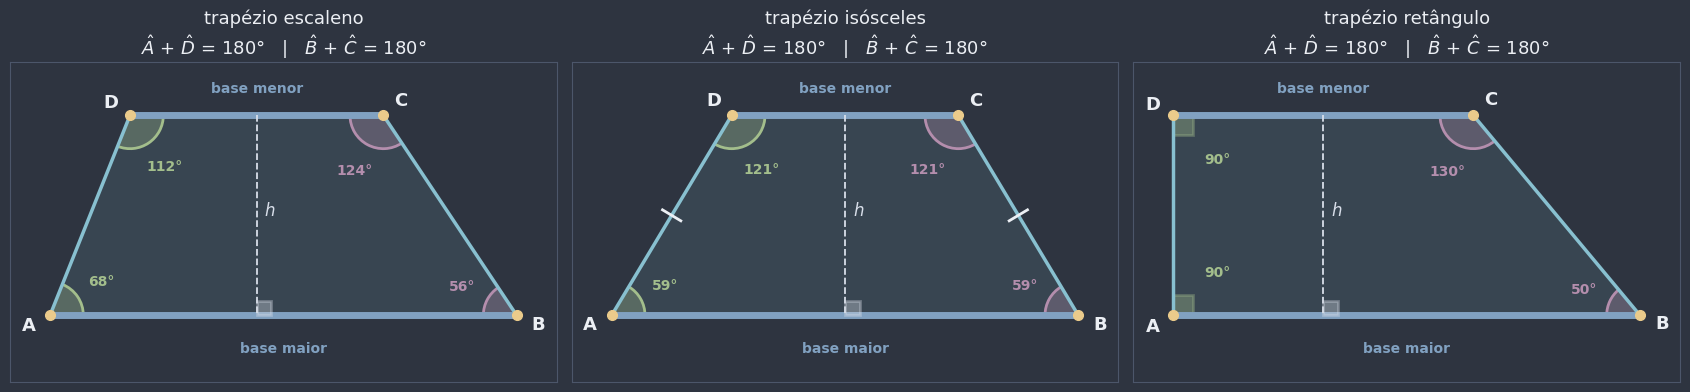

In [17]:
def classificar_trapezio(vertices) -> str:
    """Classifica o trapézio ABCD de bases AB e DC: 'escaleno', 'isósceles', 'retângulo' ou,
    se os outros dois lados também forem paralelos, 'paralelogramo'."""
    A, B, C, D = vertices
    if sao_paralelos(B, C, A, D):
        return "paralelogramo"
    if any(math.isclose(a, 90, abs_tol=1e-6) for a in angulos_internos(vertices)):
        return "retângulo"
    if math.isclose(math.dist(A, D), math.dist(B, C)):
        return "isósceles"
    return "escaleno"


def desenhar_trapezio(ax, vertices, raio: float = 0.5) -> list[float]:
    """Desenha o trapézio ABCD de bases horizontais AB e DC: bases em azul-escuro, lados não
    paralelos em azul-claro, a altura tracejada e os ângulos aos pares de colaterais internos
    (Â e D̂ em verde, B̂ e Ĉ em lilás). Devolve as medidas dos ângulos internos."""
    A, B, C, D = vertices
    ax.add_patch(Polygon(vertices, closed=True, facecolor=COR_PONTO, alpha=0.12, edgecolor="none"))
    for P, Q in ((A, B), (D, C)):
        ax.plot(*zip(P, Q), color=COR_SECUNDARIA, lw=5, solid_capstyle="round")
    for P, Q in ((B, C), (D, A)):
        ax.plot(*zip(P, Q), color=COR_PONTO, lw=2.5)
    # A altura pode ser traçada em qualquer ponto entre as bases: escolhemos o meio da faixa em comum
    x_altura = (max(A[0], D[0]) + min(B[0], C[0])) / 2
    pe, topo = np.array([x_altura, A[1]]), np.array([x_altura, D[1]])
    ax.plot(*zip(topo, pe), color=NORD_TEXTO_SEC, lw=1.3, linestyle="--")
    marcar_angulo_reto(ax, pe, pe + (1, 0), topo, tamanho=0.22, cor=NORD_TEXTO_SEC)
    ax.text(x_altura + 0.12, (A[1] + D[1]) / 2, "h", color=NORD_TEXTO_SEC, fontsize=12, style="italic")
    angulos = desenhar_angulos_internos(ax, vertices, raio=raio, raio_rotulo=1.85 * raio, tamanho_fonte=10,
                                        cores=[COR_DESTAQUE, COR_EXTRA, COR_EXTRA, COR_DESTAQUE])
    rotular_vertices(ax, vertices, distancia=0.35)
    return angulos


TRAPEZIOS = {
    "escaleno": [(0, 0), (7, 0), (5, 3), (1.2, 3)],
    "isósceles": [(0, 0), (7, 0), (5.2, 3), (1.8, 3)],
    "retângulo": [(0, 0), (7, 0), (4.5, 3), (0, 3)],
}
TRAPEZIOS = {nome: [np.array(v, dtype=float) for v in vertices] for nome, vertices in TRAPEZIOS.items()}

linhas = []
for nome, vertices in TRAPEZIOS.items():
    A, B, C, D = vertices
    a_A, a_B, a_C, a_D = angulos_internos(vertices)
    linhas.append({
        "trapézio": nome,
        "AD": f"{math.dist(A, D):.2f}", "BC": f"{math.dist(B, C):.2f}",
        "Â": f"{a_A:.1f}°", "B̂": f"{a_B:.1f}°", "Ĉ": f"{a_C:.1f}°", "D̂": f"{a_D:.1f}°",
        "Â + D̂": f"{a_A + a_D:.1f}°", "B̂ + Ĉ": f"{a_B + a_C:.1f}°",
        "classificar_trapezio": classificar_trapezio(vertices),
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

fig, eixos = plt.subplots(1, 3, figsize=(17, 4.6))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (nome, vertices) in zip(eixos, TRAPEZIOS.items()):
    A, B, C, D = vertices
    preparar_eixo(ax, [(-0.6, -1.0), (7.6, 3.8)], margem=0)
    a_A, a_B, a_C, a_D = desenhar_trapezio(ax, vertices)
    ax.text(3.5, -0.55, "base maior", color=COR_SECUNDARIA, fontsize=10, ha="center", fontweight="bold")
    ax.text((C[0] + D[0]) / 2, 3.35, "base menor", color=COR_SECUNDARIA, fontsize=10, ha="center",
            fontweight="bold")
    if nome == "isósceles":
        marcar_congruentes(ax, A, D)
        marcar_congruentes(ax, B, C)
    ax.set_title(f"trapézio {nome}\n{chapeu('A')} + {chapeu('D')} = {a_A + a_D:.0f}°   |   "
                 f"{chapeu('B')} + {chapeu('C')} = {a_B + a_C:.0f}°", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

Em verde, os ângulos colaterais internos do lado esquerdo ($\hat{A}$ e $\hat{D}$); em lilás, os do lado direito ($\hat{B}$ e $\hat{C}$). Nos três trapézios, cada par soma 180°. No isósceles, os tracinhos marcam os lados congruentes, e os ângulos de cada base saem iguais ($\hat{A} = \hat{B}$ e $\hat{C} = \hat{D}$); no retângulo, os dois ângulos retos ficam do mesmo lado.

⚠️ **Erro comum:** achar que o trapézio isósceles tem os **quatro** lados ou os **quatro** ângulos congruentes. "Isósceles" fala só dos **lados não paralelos** ($AD = BC$). As bases continuam com medidas diferentes, e os ângulos são congruentes só **dentro de cada base**: $\hat{A} = \hat{B}$ (agudos, na base maior) e $\hat{C} = \hat{D}$ (obtusos, na base menor).

🕹️ **Widget interativo:** a base maior $\overline{AB}$ (8 unidades) e a altura (3) estão fixas. O slider `base menor` muda o comprimento de $\overline{DC}$, e o slider `deslocamento` empurra a base menor para a esquerda ou para a direita (é a coordenada $x$ do vértice $D$). Procure as posições em que o trapézio fica:
- **isósceles** (dica: a base menor precisa ficar bem no meio, com sobras iguais dos dois lados);
- **retângulo** (dica: $D$ exatamente em cima de $A$, ou $C$ exatamente em cima de $B$);
- e, com a base menor igual à maior, um **paralelogramo**.

In [18]:
def explorar_trapezio(base_menor: float, deslocamento: float) -> None:
    A, B = np.array([0.0, 0.0]), np.array([8.0, 0.0])
    D = np.array([deslocamento, 3.0])
    C = D + (base_menor, 0)
    vertices = [A, B, C, D]
    tipo = classificar_trapezio(vertices)
    fig, ax = plt.subplots(figsize=(11, 4.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(min(0, deslocamento) - 0.8, -0.8), (max(8, C[0]) + 0.8, 3.7)], margem=0)
    a_A, a_B, a_C, a_D = desenhar_trapezio(ax, vertices, raio=0.45)
    centro = np.mean(vertices, axis=0)
    rotular_lado(ax, A, D, f"AD = {math.dist(A, D):.2f}", centro, cor=COR_PONTO, distancia=0.75)
    rotular_lado(ax, B, C, f"BC = {math.dist(B, C):.2f}", centro, cor=COR_PONTO, distancia=0.75)
    if tipo in ("isósceles", "paralelogramo"):
        marcar_congruentes(ax, A, D)
        marcar_congruentes(ax, B, C)
    mensagens = {
        "escaleno": ("trapézio ESCALENO: os lados não paralelos têm medidas diferentes", COR_PONTO),
        "isósceles": (f"trapézio ISÓSCELES: AD = BC, {chapeu('A')} = {chapeu('B')} e {chapeu('C')} = {chapeu('D')}",
                      COR_DESTAQUE),
        "retângulo": ("trapézio RETÂNGULO: um lado não paralelo é perpendicular às bases", COR_AVISO),
        "paralelogramo": ("bases iguais: virou PARALELOGRAMO, o trapézio especial do próximo notebook", COR_EXTRA),
    }
    mensagem, cor = mensagens[tipo]
    ax.set_title(f"{mensagem}\n{chapeu('A')} + {chapeu('D')} = {a_A + a_D:.0f}°   |   "
                 f"{chapeu('B')} + {chapeu('C')} = {a_B + a_C:.0f}°", color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_trapezio,
    base_menor=widgets.FloatSlider(value=4, min=0.5, max=8, step=0.5, description="base menor:"),
    deslocamento=widgets.FloatSlider(value=1, min=-2, max=6, step=0.5, description="deslocamento:"),
);

interactive(children=(FloatSlider(value=4.0, description='base menor:', max=8.0, min=0.5, step=0.5), FloatSlid…

🎯 **Aplicação prática — rampas, telhados e calhas:** o perfil de uma rampa de skate, a lateral de um telhado de quatro águas e o corte de uma calha são trapézios, quase sempre **isósceles** (para que os dois lados tenham a mesma inclinação). A propriedade 2 é o que garante, na obra, que basta cortar as duas peças laterais com o mesmo comprimento para que os ângulos dos dois lados saiam iguais.

📖 **Leitura complementar:** [Trapézio (geometria)](https://pt.wikipedia.org/wiki/Trap%C3%A9zio_%28geometria%29) (definição e tipos de trapézio)

**Pergunta de checagem:** em um trapézio isósceles, os dois ângulos da base maior são sempre congruentes entre si. Isso também vale para os ângulos da base menor? E um ângulo da base maior é congruente a um da base menor?

**Pergunta de checagem:** num trapézio, $\hat{A} = 70^\circ$ e $\hat{B} = 55^\circ$ (ambos na base maior). Quanto medem $\hat{C}$ e $\hat{D}$? O trapézio é isósceles?

## 5. Base média do trapézio (e a do triângulo)

📌 **Definição formal (base média do trapézio):** a **base média** do trapézio $ABCD$ (bases $\overline{AB}$ e $\overline{DC}$) é o segmento $\overline{MN}$ que liga os **pontos médios** dos dois lados não paralelos: $M$ é o ponto médio de $\overline{AD}$ e $N$ é o ponto médio de $\overline{BC}$.

📌 **Teorema (base média do trapézio):** a base média é **paralela** às duas bases, e a sua medida é a **média aritmética** das bases:

$$MN = \frac{AB + DC}{2} = \frac{B + b}{2}.$$

O nome "base média" é literal: ela fica no meio do caminho entre as bases, e o seu comprimento também fica "no meio" entre os comprimentos delas.

A demonstração usa uma prima mais simples dessa ideia, que mora dentro do triângulo:

📌 **Teorema (base média do triângulo):** o segmento que liga os pontos médios de dois lados de um triângulo é **paralelo** ao terceiro lado e mede **metade** dele.

Por enquanto vamos aceitar esse teorema, conferindo-o com números logo abaixo; a demonstração completa, com congruência de triângulos, é o Desafio 6 dos exercícios. Com ele, a base média do trapézio sai assim. Seja $P$ o ponto médio da diagonal $\overline{AC}$:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $\overline{MP} \parallel \overline{DC}$ e $MP = \dfrac{DC}{2}$ | base média do triângulo $ACD$ ($M$ e $P$ são pontos médios de $\overline{AD}$ e $\overline{AC}$) |
| 2 | $\overline{PN} \parallel \overline{AB}$ e $PN = \dfrac{AB}{2}$ | base média do triângulo $CAB$ ($P$ e $N$ são pontos médios de $\overline{CA}$ e $\overline{CB}$) |
| 3 | $\overleftrightarrow{MP}$ e $\overleftrightarrow{PN}$ passam por $P$ e são paralelas a $\overleftrightarrow{AB}$ | passos 1 e 2, e $\overline{DC} \parallel \overline{AB}$ (hipótese) |
| 4 | $M$, $P$ e $N$ estão numa mesma reta, paralela às bases | postulado das paralelas (0406a): por $P$ passa **uma única** paralela a $\overleftrightarrow{AB}$ |
| 5 | $MN = MP + PN = \dfrac{DC}{2} + \dfrac{AB}{2} = \dfrac{AB + DC}{2}$ | passos 1, 2 e 4 ∎ |

Repare no truque do passo 4: a **paralela auxiliar** de [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) aparece aqui disfarçada. As duas metades da base média são paralelas às bases e passam pelo mesmo ponto $P$; como só existe uma paralela por $P$, elas formam um segmento reto só.

**E se a base menor encolher até sumir?** Com $DC = 0$, os vértices $C$ e $D$ se juntam num ponto só e o trapézio vira o **triângulo** $ABC$. A fórmula continua funcionando: $MN = \dfrac{AB + 0}{2} = \dfrac{AB}{2}$, que é exatamente a base média do triângulo. O triângulo é um "trapézio degenerado".

**A representação numérica.** A função `base_media` calcula os pontos médios $M$ e $N$ e a medida de $\overline{MN}$; a tabela compara com a fórmula e confere o paralelismo, inclusive num trapézio inclinado, num "quase triângulo" e no próprio triângulo ($C = D$).

In [19]:
def base_media(vertices) -> tuple[np.ndarray, np.ndarray, float]:
    """Pontos médios M (de AD) e N (de BC) do trapézio ABCD de bases AB e DC, e a medida de MN."""
    A, B, C, D = vertices
    M, N = ponto_medio(A, D), ponto_medio(B, C)
    return M, N, math.dist(M, N)


EXEMPLOS_BASE_MEDIA = {
    "isósceles": [(0, 0), (8, 0), (6, 3), (2, 3)],
    "escaleno": [(0, 0), (9, 0), (6, 4), (1, 4)],
    "retângulo": [(0, 0), (7, 0), (3, 2.5), (0, 2.5)],
    "inclinado": [(0, 0), (8, 4), (5, 5), (1, 3)],
    "quase triângulo": [(0, 0), (8, 0), (3.05, 4), (2.95, 4)],
    "triângulo (C = D)": [(0, 0), (8, 0), (3, 4), (3, 4)],
}
linhas = []
for nome, vertices in EXEMPLOS_BASE_MEDIA.items():
    A, B, C, D = (np.array(v, dtype=float) for v in vertices)
    M, N, medida = base_media([A, B, C, D])
    base_maior, base_menor = math.dist(A, B), math.dist(D, C)
    formula = (base_maior + base_menor) / 2
    linhas.append({
        "trapézio": nome,
        "AB": f"{base_maior:.3f}", "DC": f"{base_menor:.3f}",
        "(AB + DC)/2": f"{formula:.3f}",
        "MN medido": f"{medida:.3f}",
        "MN ∥ AB?": "✅" if sao_paralelos(M, N, A, B) else "❌",
        "confere?": "✅" if math.isclose(medida, formula) else "❌",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

trapézio,AB,DC,(AB + DC)/2,MN medido,MN ∥ AB?,confere?
isósceles,8.000,4.000,6.000,6.000,✅,✅
escaleno,9.000,5.000,7.000,7.000,✅,✅
retângulo,7.000,3.000,5.000,5.000,✅,✅
inclinado,8.944,4.472,6.708,6.708,✅,✅
quase triângulo,8.000,0.100,4.050,4.050,✅,✅
triângulo (C = D),8.000,0.000,4.000,4.000,✅,✅


Agora a representação gráfica. À esquerda, a demonstração: a diagonal $\overline{AC}$, o seu ponto médio $P$ e as duas metades da base média, cada uma base média de um triângulo. À direita, a base média do triângulo, com os tracinhos marcando as metades congruentes de cada lado.

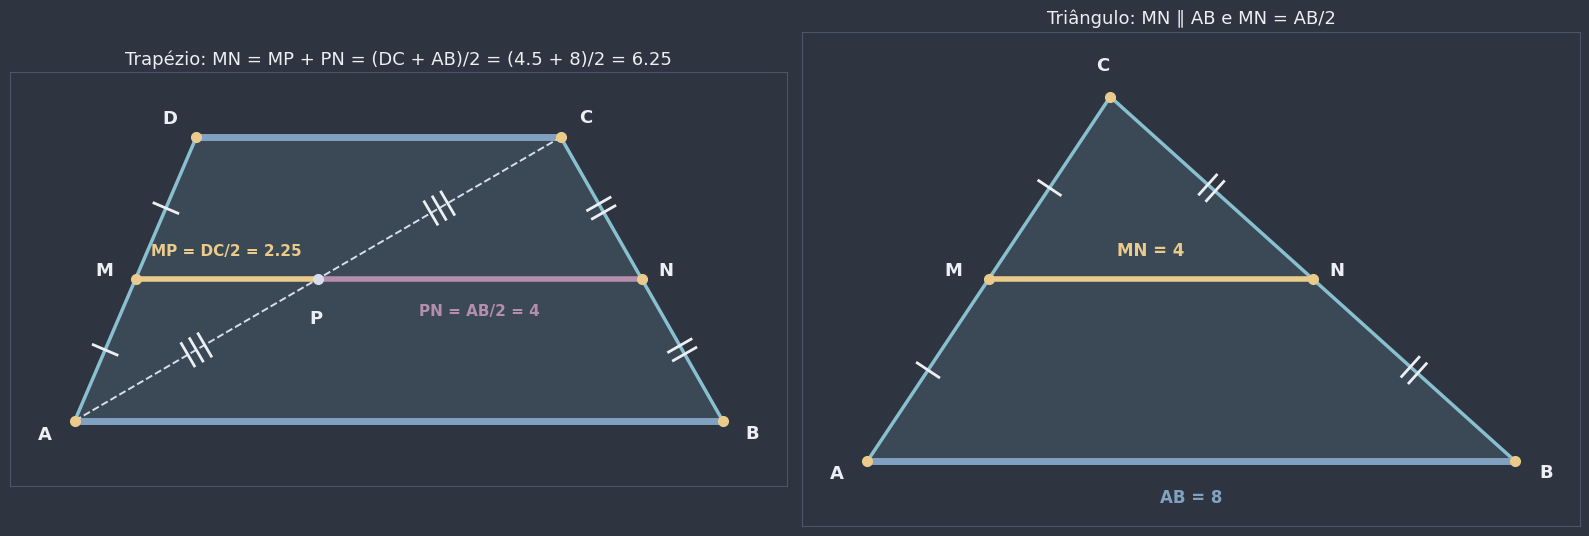

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.6))
fig.patch.set_facecolor(NORD_FUNDO)

# Esquerda: a base média do trapézio montada com duas bases médias de triângulos
A, B, C, D = (np.array(v) for v in [(0.0, 0.0), (8.0, 0.0), (6.0, 3.5), (1.5, 3.5)])
M, N, medida = base_media([A, B, C, D])
P = ponto_medio(A, C)
preparar_eixo(ax1, [A, B, C, D], margem=0.8)
desenhar_quadrilatero(ax1, [A, B, C, D], cor=COR_PONTO, largura=2.5)
for X, Y in ((A, B), (D, C)):
    ax1.plot(*zip(X, Y), color=COR_SECUNDARIA, lw=5, solid_capstyle="round")
ax1.plot(*zip(A, C), color=NORD_TEXTO_SEC, lw=1.4, linestyle="--")
ax1.plot(*zip(M, P), color=COR_AVISO, lw=4)
ax1.plot(*zip(P, N), color=COR_EXTRA, lw=4)
ax1.text(*(ponto_medio(M, P) + (0, 0.3)), f"MP = DC/2 = {math.dist(M, P):g}", color=COR_AVISO, fontsize=11,
         ha="center", fontweight="bold")
ax1.text(*(ponto_medio(P, N) + (0, -0.45)), f"PN = AB/2 = {math.dist(P, N):g}", color=COR_EXTRA, fontsize=11,
         ha="center", fontweight="bold")
for X, Y, tracos in ((A, D, 1), (B, C, 2), (A, C, 3)):
    marcar_congruentes(ax1, X, ponto_medio(X, Y), tracos)
    marcar_congruentes(ax1, ponto_medio(X, Y), Y, tracos)
rotular_vertices(ax1, [A, B, C, D], distancia=0.4)
desenhar_ponto(ax1, M, "M", deslocamento=(-0.5, 0.05))
desenhar_ponto(ax1, N, "N", deslocamento=(0.2, 0.05))
desenhar_ponto(ax1, P, "P", cor=NORD_TEXTO_SEC, deslocamento=(-0.1, -0.55))
ax1.set_title(f"Trapézio: MN = MP + PN = (DC + AB)/2 = ({math.dist(D, C):g} + {math.dist(A, B):g})/2 = {medida:g}",
              color=NORD_TEXTO, fontsize=13)

# Direita: a base média do triângulo
A, B, C = (np.array(v) for v in [(0.0, 0.0), (8.0, 0.0), (3.0, 4.5)])
M, N = ponto_medio(A, C), ponto_medio(B, C)
preparar_eixo(ax2, [A, B, C], margem=0.8)
desenhar_quadrilatero(ax2, [A, B, C], cor=COR_PONTO, largura=2.5)
ax2.plot(*zip(A, B), color=COR_SECUNDARIA, lw=5, solid_capstyle="round")
ax2.plot(*zip(M, N), color=COR_AVISO, lw=4)
for X, Y, tracos in ((A, C, 1), (B, C, 2)):
    marcar_congruentes(ax2, X, ponto_medio(X, Y), tracos)
    marcar_congruentes(ax2, ponto_medio(X, Y), Y, tracos)
ax2.text(*(ponto_medio(M, N) + (0, 0.3)), f"MN = {math.dist(M, N):g}", color=COR_AVISO, fontsize=12,
         ha="center", fontweight="bold")
ax2.text(4, -0.5, f"AB = {math.dist(A, B):g}", color=COR_SECUNDARIA, fontsize=12, ha="center", fontweight="bold")
rotular_vertices(ax2, [A, B, C], "ABC", distancia=0.4)
desenhar_ponto(ax2, M, "M", deslocamento=(-0.55, 0.05))
desenhar_ponto(ax2, N, "N", deslocamento=(0.2, 0.05))
ax2.set_title("Triângulo: MN ∥ AB e MN = AB/2", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** os sliders mudam a `base de baixo` ($AB$) e a `base de cima` ($DC$) do trapézio. À esquerda, a figura com a base média $\overline{MN}$ em amarelo; à direita, as três medidas lado a lado, como barras: repare que a barra da base média fica sempre **exatamente no meio** das outras duas.

💡 **Dica — o caso limite:** leve a `base de cima` até **0**. Os vértices $C$ e $D$ se juntam, o trapézio vira um triângulo, e a base média do trapézio vira a base média do triângulo, com metade da base de baixo. (A fórmula também não liga para qual base é a maior: experimente deixar a de cima maior que a de baixo.)

In [22]:
def explorar_base_media(base_baixo: float, base_cima: float) -> None:
    A, B = np.array([0.0, 0.0]), np.array([base_baixo, 0.0])
    D = np.array([1.5, 3.5])
    C = D + (base_cima, 0)
    M, N, medida = base_media([A, B, C, D])
    triangulo = base_cima == 0
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.4, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)

    preparar_eixo(ax1, [(-0.8, -1.0), (12.3, 4.3)], margem=0)
    vertices = [A, B, C] if triangulo else [A, B, C, D]
    desenhar_quadrilatero(ax1, vertices, cor=COR_PONTO, largura=2.5)
    ax1.plot(*zip(A, B), color=COR_SECUNDARIA, lw=5, solid_capstyle="round")
    if not triangulo:
        ax1.plot(*zip(D, C), color=COR_SECUNDARIA, lw=5, solid_capstyle="round")
    ax1.plot(*zip(M, N), color=COR_AVISO, lw=4)
    rotular_vertices(ax1, vertices, ["A", "B", "C = D"] if triangulo else "ABCD", distancia=0.4)
    desenhar_ponto(ax1, M, "M", deslocamento=(-0.55, 0.05))
    desenhar_ponto(ax1, N, "N", deslocamento=(0.2, 0.05))
    if triangulo:
        titulo, cor = "base de cima = 0: o trapézio virou o triângulo ABC,\ne MN virou a base média do triângulo (AB/2)", COR_EXTRA
    else:
        titulo, cor = f"Trapézio ABCD: a base média MN mede {medida:.2f}", NORD_TEXTO
    ax1.set_title(titulo, color=cor, fontsize=13)

    estilizar_eixo(ax2)
    nomes = ["base de cima (DC)", "base média (MN)", "base de baixo (AB)"]
    medidas = [base_cima, medida, base_baixo]
    ax2.barh(nomes, medidas, color=[COR_SECUNDARIA, COR_AVISO, COR_SECUNDARIA], height=0.55)
    for posicao, valor in enumerate(medidas):
        ax2.text(valor + 0.15, posicao, f"{valor:.2f}", color=NORD_TEXTO, va="center", fontsize=12)
    ax2.set_xlim(0, 12)
    ax2.tick_params(axis="y", labelsize=11, colors=NORD_TEXTO)
    ax2.set_title(f"(AB + DC)/2 = ({base_baixo:g} + {base_cima:g})/2 = {(base_baixo + base_cima) / 2:g}  "
                  f"{'✓' if math.isclose(medida, (base_baixo + base_cima) / 2) else '✗'}",
                  color=COR_DESTAQUE, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_base_media,
    base_baixo=widgets.FloatSlider(value=8, min=2, max=10, step=0.5, description="base de baixo:"),
    base_cima=widgets.FloatSlider(value=3, min=0, max=10, step=0.5, description="base de cima:"),
);

interactive(children=(FloatSlider(value=8.0, description='base de baixo:', max=10.0, min=2.0, step=0.5), Float…

🎯 **Aplicação prática — canais, valas e moldes de costura:** canais de irrigação e valas de drenagem costumam ter a seção (o "corte") em forma de trapézio: fundo estreito, boca larga. Num canal com fundo de 2 m, boca de 6 m e 1,5 m de profundidade, a largura da água cresce de forma constante do fundo até a boca, e **na metade da profundidade** ela é exatamente a base média, $(2 + 6)/2 = 4$ m. Os engenheiros usam essa "largura média" para estimar a área da seção e a vazão do canal (as áreas vêm no fim deste módulo). Na costura, o raciocínio é o mesmo: o molde de uma saia evasê é um trapézio, e a medida na metade da altura (a base média) dá o contorno no meio do quadril, sem precisar medir.

Repare também que, no canal, a base **maior** está em cima: num trapézio, "base" não quer dizer "o lado de baixo".

altura da água (m),largura da superfície (m),observação
0,2,fundo (base menor)
0.375,3,
0.75,4,metade da profundidade: base média!
1.125,5,
1.5,6,boca (base maior)


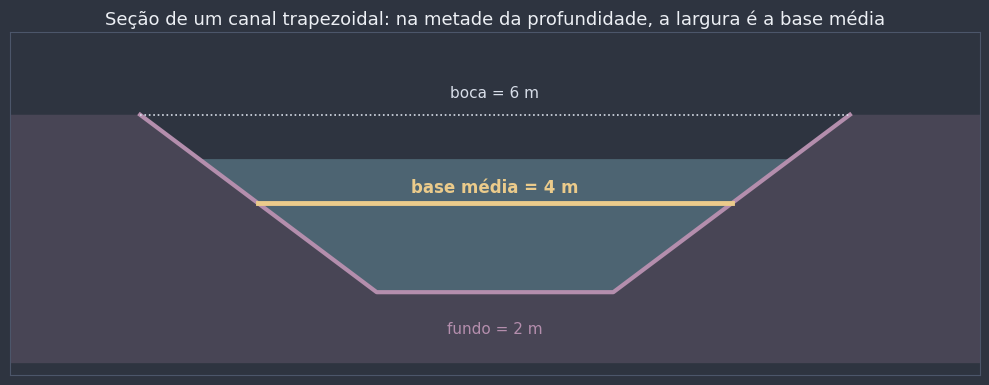

In [23]:
fundo, boca, profundidade = 2.0, 6.0, 1.5


def largura_da_agua(nivel: float) -> float:
    """Largura da superfície da água no canal quando ela está `nivel` metros acima do fundo."""
    return fundo + (boca - fundo) * nivel / profundidade


niveis = [0, 0.375, 0.75, 1.125, 1.5]
display(pd.DataFrame([
    {"altura da água (m)": f"{n:g}", "largura da superfície (m)": f"{largura_da_agua(n):g}",
     "observação": {0: "fundo (base menor)", 0.75: "metade da profundidade: base média!",
                    1.5: "boca (base maior)"}.get(n, "")}
    for n in niveis
]).style.hide(axis="index"))

fig, ax = plt.subplots(figsize=(10, 4.4))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-4, -0.6), (4, 2.1)], margem=0.1)
ax.add_patch(Polygon([(-4.2, 1.5), (-3, 1.5), (-1, 0), (1, 0), (3, 1.5), (4.2, 1.5), (4.2, -0.6), (-4.2, -0.6)],
                     closed=True, facecolor=COR_EXTRA, alpha=0.2, edgecolor="none"))  # o terreno
ax.add_patch(Polygon([(-1, 0), (1, 0), (2.5, 1.125), (-2.5, 1.125)], closed=True, facecolor=COR_PONTO,
                     alpha=0.35, edgecolor="none"))  # a água
ax.plot([-3, -1, 1, 3], [1.5, 0, 0, 1.5], color=COR_EXTRA, lw=3)
ax.plot([-3, 3], [1.5, 1.5], color=NORD_TEXTO_SEC, lw=1.2, linestyle=":")
meia_largura = largura_da_agua(0.75) / 2
ax.plot([-meia_largura, meia_largura], [0.75, 0.75], color=COR_AVISO, lw=3.5)
ax.text(0, 0.85, f"base média = {largura_da_agua(0.75):g} m", color=COR_AVISO, fontsize=12, ha="center",
        fontweight="bold")
ax.text(0, 1.65, f"boca = {boca:g} m", color=NORD_TEXTO_SEC, fontsize=11, ha="center")
ax.text(0, -0.35, f"fundo = {fundo:g} m", color=COR_EXTRA, fontsize=11, ha="center")
ax.set_title("Seção de um canal trapezoidal: na metade da profundidade, a largura é a base média",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

📎 **Conexão:** a base média, do triângulo e do trapézio, vai voltar como ferramenta em 📌 Triângulos Quaisquer (relações entre lados e segmentos de um triângulo qualquer) e em 📌 Áreas de Superfícies Planas, onde a área do trapézio sai como **base média × altura**, $A = \dfrac{(B + b)}{2} \cdot h$.

📖 **Leitura complementar:** [Teorema da base média do triângulo](https://pt.wikipedia.org/wiki/Teorema_da_base_m%C3%A9dia_do_tri%C3%A2ngulo)

**Pergunta de checagem:** um trapézio tem base maior de 10 cm e base menor de 4 cm. Qual é a medida da base média?

**Pergunta de checagem:** num triângulo, o segmento que liga os pontos médios de dois lados mede 6 cm. Quanto mede o terceiro lado?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Quadrilátero | 4 vértices (três consecutivos não colineares) ligados **em ordem** por 4 lados que não se cruzam (simples) |
| Elementos | 4 lados (consecutivos ou opostos), 4 ângulos internos e **2 diagonais** (ligam vértices não consecutivos: $6 - 4 = 2$) |
| Convexo × côncavo | convexo: o segmento entre dois pontos internos fica sempre dentro; côncavo: tem um ângulo interno maior que 180° |
| Rigidez | só os lados não determinam o quadrilátero; uma diagonal fixa o divide em 2 triângulos rígidos (LLL) |
| Soma dos ângulos internos | $\hat{A} + \hat{B} + \hat{C} + \hat{D} = 360^\circ$ (uma diagonal: $2 \times 180^\circ$) |
| Mapa (convenção inclusiva) | quadrilátero $\supset$ trapézio $\supset$ paralelogramo $\supset$ retângulo e losango; quadrado = retângulo **e** losango |
| Trapézio | **pelo menos um** par de lados opostos paralelos (as bases); altura = distância entre as bases |
| Tipos de trapézio | escaleno (laterais diferentes), isósceles (laterais congruentes), retângulo (uma lateral perpendicular às bases) |
| Colaterais internos | $\hat{A} + \hat{D} = 180^\circ$ e $\hat{B} + \hat{C} = 180^\circ$ (paralelas cortadas por transversal) |
| Trapézio isósceles | $\hat{A} = \hat{B}$ e $\hat{C} = \hat{D}$ (alturas + caso hipotenusa-cateto) |
| Base média do trapézio | liga os pontos médios das laterais; paralela às bases e $MN = \dfrac{B + b}{2}$ |
| Base média do triângulo | liga os pontos médios de dois lados; paralela ao terceiro e mede **metade** dele (o caso $b = 0$ do trapézio) |

**A ideia central:** quase tudo sobre quadriláteros sai de **dividi-los em triângulos**. Uma diagonal dá a soma de 360° e trava a forma; as alturas mostram a simetria do trapézio isósceles; e a base média do trapézio é a soma de duas bases médias de triângulos.

## Exercícios

**Básico**
1. Calcular o ângulo que falta num quadrilátero, conhecidos os outros três.
2. Classificar trapézios (escaleno, isósceles ou retângulo) a partir das medidas dos lados não paralelos e dos ângulos da base maior.

**Intermediário**

3. Num trapézio isósceles dado por coordenadas, medir os ângulos da base maior e conferir a congruência dos triângulos formados pelas alturas.
4. Escrever uma função que calcula a base média de um trapézio dado pelos vértices, e testá-la contra a fórmula.

**Desafio**

5. O problema inverso: dadas a base média e uma das bases, encontrar a outra.
6. A base média do triângulo, conferida com distâncias e inclinações (e demonstrada no gabarito).

Gabarito completo com resolução comentada em [`0408b_quadrilateros_definicao_elementos_e_trapezios_gabarito.ipynb`](0408b_quadrilateros_definicao_elementos_e_trapezios_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: complete a função `angulo_faltante_ex1`, que recebe as medidas (em graus) de
# três ângulos internos de um quadrilátero e devolve a medida do quarto.
# Depois, use a função para responder: um terreno de quatro lados tem cantos de 80°, 95° e 120°.
# Quanto mede o quarto canto? Guarde em `quarto_canto_ex1`.


def angulo_faltante_ex1(angulo_1: float, angulo_2: float, angulo_3: float) -> float:
    ...


quarto_canto_ex1 = ...

print(angulo_faltante_ex1(90, 90, 90))
print(quarto_canto_ex1)

In [ ]:
# Verificação
casos_ex1 = [
    (90, 90, 90, 90),
    (80, 95, 120, 65),
    (100, 100, 100, 60),
    (45.5, 134.5, 90, 90),
    (200, 50, 60, 50),  # um quadrilátero côncavo: o primeiro ângulo passa de 180°
]
for a1, a2, a3, certo in casos_ex1:
    resposta = angulo_faltante_ex1(a1, a2, a3)
    assert resposta is not None and resposta is not ... and math.isclose(resposta, certo), (
        f"Tente de novo, revise: com {a1}°, {a2}° e {a3}°, o quarto ângulo deveria ser {certo}°; "
        "os quatro somam 360° (seção 2 - Soma dos ângulos internos de um quadrilátero)."
    )
assert quarto_canto_ex1 is not ... and math.isclose(quarto_canto_ex1, 65), (
    "Tente de novo, revise: o quarto canto é 360° − (80° + 95° + 120°) (seção 2 - Soma dos ângulos internos de um quadrilátero)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: complete a função `classificar_trapezio_ex2`. Ela recebe as medidas dos dois
# lados não paralelos de um trapézio (`lateral_1` e `lateral_2`) e as medidas dos dois ângulos da
# base maior (`angulo_A` e `angulo_B`, em graus), e devolve um destes textos:
#   "retângulo"  se algum dos ângulos da base maior for reto;
#   "isósceles"  se os lados não paralelos forem congruentes;
#   "escaleno"   nos outros casos.
# Teste primeiro o caso "retângulo". Compare medidas com math.isclose, não com ==.
# (Pode supor que o trapézio não é um paralelogramo.)


def classificar_trapezio_ex2(lateral_1: float, lateral_2: float, angulo_A: float, angulo_B: float) -> str:
    ...


print(classificar_trapezio_ex2(5, 5, 60, 60))
print(classificar_trapezio_ex2(3, 6, 70, 30))

In [ ]:
# Verificação
casos_ex2 = [
    (5, 5, 60, 60, "isósceles"),
    (4, 5, 90, 53.13, "retângulo"),
    (3, 6, 70, 30, "escaleno"),
    (7.5, 7.5, 48, 48, "isósceles"),
    (6, 4.2, 45, 90, "retângulo"),
    (0.1 + 0.2, 0.3, 75, 75, "isósceles"),  # 0.1 + 0.2 não é exatamente 0.3 no computador!
    (2, 2.5, 80, 65, "escaleno"),
]
for lateral_1, lateral_2, angulo_A, angulo_B, certo in casos_ex2:
    resposta = classificar_trapezio_ex2(lateral_1, lateral_2, angulo_A, angulo_B)
    assert resposta == certo, (
        f"Tente de novo, revise: laterais {lateral_1:g} e {lateral_2:g}, ângulos da base {angulo_A}° e "
        f"{angulo_B}° formam um trapézio {certo}, mas a função devolveu {resposta!r} "
        "(seção 4 - Trapézios: elementos e propriedades)."
    )
print("Certo!")

### Intermediário

Execute a célula abaixo para ver a figura do Exercício Intermediário 3.

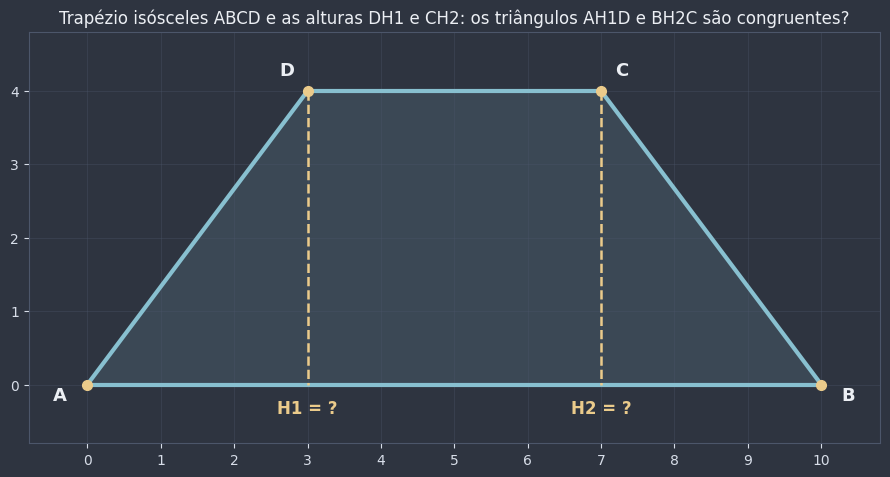

In [22]:
# Figura do Exercício Intermediário 3 (apenas desenha; não precisa alterar)
trapezio_3 = [np.array(v, dtype=float) for v in [(0, 0), (10, 0), (7, 4), (3, 4)]]
fig, ax = plt.subplots(figsize=(9, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-0.5, -0.5), (10.5, 4.5)], margem=0.3)
estilizar_eixo(ax)
ax.set_xticks(range(0, 11))
ax.set_yticks(range(0, 5))
desenhar_quadrilatero(ax, trapezio_3, cor=COR_PONTO, largura=3)
for vertice in (trapezio_3[3], trapezio_3[2]):
    ax.plot([vertice[0], vertice[0]], [vertice[1], 0], color=COR_AVISO, lw=1.8, linestyle="--")
rotular_vertices(ax, trapezio_3, distancia=0.4)
ax.text(3, -0.4, "H1 = ?", color=COR_AVISO, fontsize=12, fontweight="bold", ha="center")
ax.text(7, -0.4, "H2 = ?", color=COR_AVISO, fontsize=12, fontweight="bold", ha="center")
ax.set_title("Trapézio isósceles ABCD e as alturas DH1 e CH2: os triângulos AH1D e BH2C são congruentes?",
             color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Intermediário 3: o trapézio ABCD tem vértices A = (0, 0), B = (10, 0), C = (7, 4) e
# D = (3, 4), com bases AB e DC.
# (a) Use o transferidor digital `medir_angulo` para medir os ângulos da base maior, Â (entre AB e
#     AD) e B̂ (entre BA e BC). Guarde em `angulo_A_ex3` e `angulo_B_ex3`.
# (b) As alturas DH1 e CH2 caem verticalmente sobre AB. Quais são os pés H1 e H2? Guarde-os em
#     `H1_ex3` e `H2_ex3` (como np.array).
# (c) Calcule as medidas dos três lados de cada triângulo, AH1D e BH2C, e guarde cada trio em ordem
#     crescente (use sorted) em `lados_AH1D_ex3` e `lados_BH2C_ex3`.
# (d) Os dois triângulos são congruentes? Responda True ou False em `congruentes_ex3`, e escreva em
#     `caso_ex3` a sigla do caso de congruência que você acabou de conferir com o item (c).
A_ex3, B_ex3, C_ex3, D_ex3 = trapezio_3

angulo_A_ex3 = ...
angulo_B_ex3 = ...
H1_ex3 = ...
H2_ex3 = ...
lados_AH1D_ex3 = ...
lados_BH2C_ex3 = ...
congruentes_ex3 = ...
caso_ex3 = ...

print(angulo_A_ex3, angulo_B_ex3)
print(lados_AH1D_ex3, lados_BH2C_ex3, congruentes_ex3, caso_ex3)

In [ ]:
# Verificação
assert angulo_A_ex3 is not ... and math.isclose(angulo_A_ex3, math.degrees(math.atan2(4, 3))), (
    "Tente de novo, revise: Â = medir_angulo(A_ex3, B_ex3, D_ex3) (seção 4 - Trapézios: elementos e propriedades)."
)
assert angulo_B_ex3 is not ... and math.isclose(angulo_B_ex3, angulo_A_ex3), (
    "Tente de novo, revise: B̂ = medir_angulo(B_ex3, A_ex3, C_ex3), e num trapézio isósceles Â = B̂ "
    "(seção 4 - Trapézios: elementos e propriedades)."
)
assert H1_ex3 is not ... and np.allclose(H1_ex3, [3, 0]) and H2_ex3 is not ... and np.allclose(H2_ex3, [7, 0]), (
    "Tente de novo, revise: o pé da altura vertical tem o mesmo x do vértice e y = 0 (seção 4 - Trapézios: elementos e propriedades)."
)
assert lados_AH1D_ex3 is not ... and np.allclose(sorted(lados_AH1D_ex3), [3, 4, 5]), (
    "Tente de novo, revise: os lados de AH1D são AH1, H1D e AD; use math.dist (seção 4 - Trapézios: elementos e propriedades)."
)
assert lados_BH2C_ex3 is not ... and np.allclose(sorted(lados_BH2C_ex3), [3, 4, 5]), (
    "Tente de novo, revise: os lados de BH2C são BH2, H2C e BC; use math.dist (seção 4 - Trapézios: elementos e propriedades)."
)
assert congruentes_ex3 is True and caso_ex3 == "LLL", (
    "Tente de novo, revise: três lados correspondentes congruentes é o caso LLL (seção 4 - Trapézios: elementos e propriedades)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: complete a função `base_media_ex4`, que recebe os vértices A, B, C, D
# (como np.array) de um trapézio de bases AB e DC e devolve a MEDIDA da base média.
# Passos: M é o ponto médio de AD, N é o ponto médio de BC, e a resposta é a distância MN.
# Pode usar `ponto_medio` (da célula de ferramentas) ou a fórmula de 0402a, e math.dist.
# A verificação vai testar a função em vários trapézios, comparando com (AB + DC) / 2.


def base_media_ex4(A, B, C, D) -> float:
    ...


print(base_media_ex4(np.array([0.0, 0.0]), np.array([8.0, 0.0]), np.array([6.0, 3.0]), np.array([2.0, 3.0])))

In [ ]:
# Verificação
casos_ex4 = [
    [(0, 0), (8, 0), (6, 3), (2, 3)],
    [(0, 0), (10, 0), (7, 4), (3, 4)],
    [(0, 0), (7, 0), (3, 2.5), (0, 2.5)],
    [(1, 1), (1, 9), (4, 7), (4, 3)],      # bases verticais
    [(0, 0), (8, 4), (5, 5), (1, 3)],      # bases inclinadas
    [(0, 0), (6, 0), (4, 5), (4, 5)],      # C = D: um triângulo
]
for vertices in casos_ex4:
    A, B, C, D = (np.array(v, dtype=float) for v in vertices)
    certo = (math.dist(A, B) + math.dist(D, C)) / 2
    resposta = base_media_ex4(A, B, C, D)
    assert resposta is not None and resposta is not ... and math.isclose(resposta, certo), (
        f"Tente de novo, revise: para o trapézio {[tuple(map(float, v)) for v in (A, B, C, D)]}, a base média "
        f"deveria medir {certo:.4f}; M é o ponto médio de AD e N o de BC (seção 5 - Base média do trapézio)."
    )
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: o problema inverso da base média.
# (a) Complete a função `outra_base_ex5`, que recebe a medida da base média e a de UMA das bases e
#     devolve a medida da outra base. Se a conta der zero ou um número negativo, não existe
#     trapézio com essas medidas: nesse caso, a função deve devolver None.
#     (Dica: isole a incógnita em  base_media = (base_conhecida + outra) / 2.)
# (b) Uma calha tem seção em forma de trapézio. A largura medida exatamente na metade da altura é
#     de 9 cm, e a abertura de cima mede 13 cm. Quanto mede o fundo da calha? Guarde em
#     `fundo_calha_ex5`.


def outra_base_ex5(base_media: float, base_conhecida: float) -> float | None:
    ...


fundo_calha_ex5 = ...

print(outra_base_ex5(7, 10), outra_base_ex5(3, 8))
print(fundo_calha_ex5)

In [ ]:
# Verificação
casos_ex5 = [(7, 10, 4), (7, 4, 10), (9, 13, 5), (6.5, 2, 11), (3, 8, None), (4, 8, None)]
for media, conhecida, certo in casos_ex5:
    resposta = outra_base_ex5(media, conhecida)
    if certo is None:
        assert resposta is None, (
            f"Tente de novo, revise: com base média {media} e uma base {conhecida}, a outra daria "
            f"{2 * media - conhecida:g}, que não é a medida de um lado: devolva None (seção 5 - Base média do trapézio)."
        )
    else:
        assert resposta is not None and resposta is not ... and math.isclose(resposta, certo), (
            f"Tente de novo, revise: com base média {media} e uma base {conhecida}, a outra mede "
            f"2 × {media} − {conhecida} = {certo} (seção 5 - Base média do trapézio)."
        )
assert fundo_calha_ex5 is not ... and math.isclose(fundo_calha_ex5, 5), (
    "Tente de novo, revise: a largura na metade da altura é a base média; o fundo é 2 × 9 − 13 (seção 5 - Base média do trapézio)."
)
print("Certo!")

Execute a célula abaixo para ver a figura do Exercício Desafio 6.

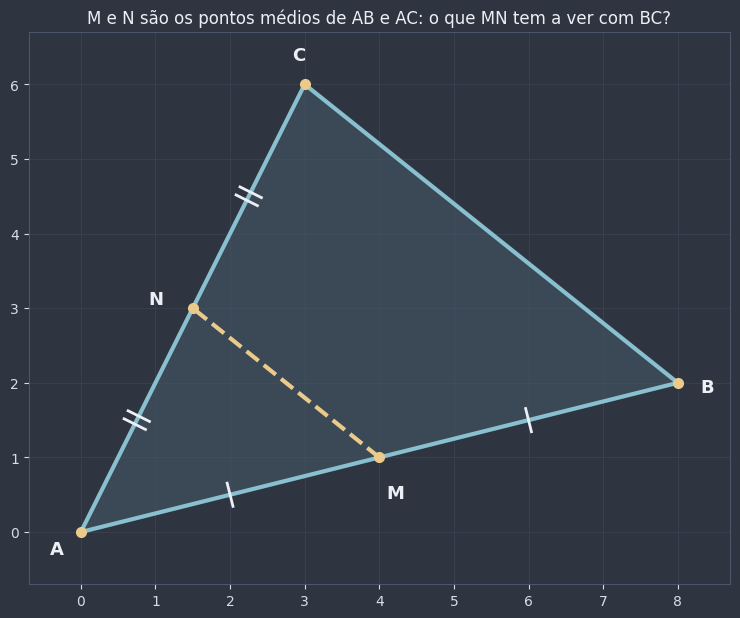

In [23]:
# Figura do Exercício Desafio 6 (apenas desenha; não precisa alterar)
triangulo_6 = [np.array(v, dtype=float) for v in [(0, 0), (8, 2), (3, 6)]]
fig, ax = plt.subplots(figsize=(7.5, 6.2))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-0.5, -0.5), (8.5, 6.5)], margem=0.2)
estilizar_eixo(ax)
ax.set_xticks(range(0, 9))
ax.set_yticks(range(0, 7))
desenhar_quadrilatero(ax, triangulo_6, cor=COR_PONTO, largura=3)
A6, B6, C6 = triangulo_6
for X, Y, tracos in ((A6, B6, 1), (A6, C6, 2)):
    marcar_congruentes(ax, X, ponto_medio(X, Y), tracos)
    marcar_congruentes(ax, ponto_medio(X, Y), Y, tracos)
ax.plot(*zip(ponto_medio(A6, B6), ponto_medio(A6, C6)), color=COR_AVISO, lw=3, linestyle="--")
rotular_vertices(ax, triangulo_6, "ABC", distancia=0.4)
desenhar_ponto(ax, ponto_medio(A6, B6), "M", deslocamento=(0.1, -0.55))
desenhar_ponto(ax, ponto_medio(A6, C6), "N", deslocamento=(-0.6, 0.05))
ax.set_title("M e N são os pontos médios de AB e AC: o que MN tem a ver com BC?", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Desafio 6: a base média do triângulo, conferida com números.
# O triângulo tem vértices A = (0, 0), B = (8, 2) e C = (3, 6).
# (a) Calcule M, o ponto médio de AB, e N, o ponto médio de AC. Guarde em `M_ex6` e `N_ex6`.
# (b) Calcule as inclinações (em graus, com `direcao_de`) do segmento MN e do lado BC. Guarde em
#     `inclinacao_MN_ex6` e `inclinacao_BC_ex6`, e responda em `paralelos_ex6` (True ou False) se MN
#     é paralelo a BC (lembre: inclinações iguais "a menos de 180°").
# (c) Calcule a razão MN / BC e guarde em `razao_ex6`.
# (d) Um exemplo só não prova nada. Sorteie 1000 triângulos com o gerador abaixo (cada vértice com
#     coordenadas entre −10 e 10), repita (a), (b) e (c) para cada um e guarde em `todos_ok_ex6`
#     True se, em TODOS eles, MN for paralelo ao terceiro lado e medir metade dele.
#     (Testar 1000 casos ainda não é demonstrar: a demonstração com congruência está no gabarito.)
A_ex6, B_ex6, C_ex6 = triangulo_6
gerador_ex6 = np.random.default_rng(6)

M_ex6 = ...
N_ex6 = ...
inclinacao_MN_ex6 = ...
inclinacao_BC_ex6 = ...
paralelos_ex6 = ...
razao_ex6 = ...
todos_ok_ex6 = ...

print(M_ex6, N_ex6, inclinacao_MN_ex6, inclinacao_BC_ex6, paralelos_ex6, razao_ex6, todos_ok_ex6)

In [ ]:
# Verificação
assert M_ex6 is not ... and np.allclose(M_ex6, [4, 1]) and N_ex6 is not ... and np.allclose(N_ex6, [1.5, 3]), (
    "Tente de novo, revise: o ponto médio é a média das coordenadas das pontas (seção 5 - Base média do trapézio)."
)
assert inclinacao_MN_ex6 is not ... and inclinacao_BC_ex6 is not ..., (
    "Tente de novo, revise: use direcao_de nos dois segmentos (seção 5 - Base média do trapézio)."
)
diferenca_ex6 = (inclinacao_MN_ex6 - direcao_de(B_ex6, C_ex6)) % 180
assert math.isclose(diferenca_ex6, 0, abs_tol=1e-9) or math.isclose(diferenca_ex6, 180, abs_tol=1e-9), (
    "Tente de novo, revise: a inclinação de MN deve ser a mesma de BC, a menos de 180° (seção 5 - Base média do trapézio)."
)
assert paralelos_ex6 is True, (
    "Tente de novo, revise: inclinações iguais a menos de 180° significam segmentos paralelos (seção 5 - Base média do trapézio)."
)
assert razao_ex6 is not ... and math.isclose(razao_ex6, 0.5), (
    "Tente de novo, revise: razao = math.dist(M, N) / math.dist(B, C) (seção 5 - Base média do trapézio)."
)
assert todos_ok_ex6 is True, (
    "Tente de novo, revise: em todo triângulo, MN é paralelo ao terceiro lado e mede metade dele; confira "
    "o laço e use math.isclose nas comparações (seção 5 - Base média do trapézio)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (ponto médio, que define a base média; distância entre dois pontos)
- [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (elementos do triângulo, rigidez e a soma 180° dos ângulos internos)
- [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (caso LLL da escora e caso hipotenusa-cateto do trapézio isósceles; LAL na demonstração da base média do triângulo)
- [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (colaterais internos suplementares, o postulado das paralelas na base média e a demonstração do 180°)
- [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (a altura do trapézio como distância entre as paralelas das bases)

**Isso será usado em:**
- 📌 Paralelogramos e Casos Particulares (continuação direta: paralelogramo, retângulo, losango e quadrado, os níveis seguintes do mapa)
- 📌 Polígonos (a soma dos ângulos internos de um polígono qualquer, dividindo-o em triângulos a partir de um vértice)
- 📌 Triângulos Quaisquer (a base média do triângulo como ferramenta)
- 📌 Áreas de Superfícies Planas (área do trapézio como base média × altura)